## libraries and File Paths

In [44]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import coolwarm
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as colors

In [45]:
# setting base directory 
dir = "/global/scratch/users/yougsanghvi"


In [46]:
# Input file paths:
# 1. setting suicide panel file path
suicide_proj_folder = "data"
suicide_panel_folderp = os.path.join("merged", "USA")
suicide_panel_filen = "USA_adm2_1968_2004_monthly.dta"
suicide_panel_filep = os.path.join(dir, suicide_proj_folder, suicide_panel_folderp, suicide_panel_filen)

# 2. Define paths for usa county shapefile
usa_county_dir = os.path.join(dir, "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)

# 3. Specific folder for attribution results
attribution_output_folderpath = os.path.join(
    dir,
    "gdnat_era5_compare_output"
)

# 4. Define the modeling input filename
attribution_output_filename = "merged_data_panel_extended.csv"

# Construct the full file path for the prev modeling data
attribution_output_filepath = os.path.join(
    attribution_output_folderpath,
    attribution_output_filename
)

# --- Load data ---
attribution_output_data = pd.read_csv(attribution_output_filepath)
suicide_panel_data = pd.read_stata(suicide_panel_filep)
usa_counties = gpd.read_file(usa_county_path)

In [47]:
# Output file paths 

# path for intermediate outputs 
output_path_intermediate = os.path.join(dir, "gdnat_intermediate_outputs")

## Data Processing

In [58]:
# Filter and select columns
filtered_suicide = suicide_panel_data[
    (suicide_panel_data["agegroup"] == 0) & (suicide_panel_data["gender"] == 0)
][[
    'fipsst', 'fipscty', 'fips', 'year', 'month', 'num_of_suicide',
    'suiciderate', 'population', 'adm1_id', 'adm2_id',
    'statename', 'countyname'
]]


In [59]:
# Tagging counties with incomplete data 

fips_1979_1988 = set(
    filtered_suicide[
        (filtered_suicide['year'] >= 1979) & 
        (filtered_suicide['year'] <= 1988) &
        (~filtered_suicide['suiciderate'].isna())
    ]['fips'].unique()
)

fips_1989plus = set(
    filtered_suicide[
        (filtered_suicide['year'] >= 1989) &
        (~filtered_suicide['suiciderate'].isna())
    ]['fips'].unique()
)

# Identify categories
fips_all_years = fips_1979_1988 & fips_1989plus
fips_only_early = fips_1979_1988 - fips_1989plus

# Create mapping
def tag_missing(fips_str):
    if pd.isna(fips_str):
        return np.nan
    fips_int = int(fips_str)
    if fips_int in fips_all_years:
        return 0
    elif fips_int in fips_only_early:
        return 1
    else:
        return np.nan

# Apply tag to dataset
filtered_suicide['missing'] = filtered_suicide['fips'].apply(tag_missing)
complete_data_suicide = filtered_suicide[filtered_suicide['missing'] == 0]


In [60]:
# merging the dataset

# Ensure ID columns are integers
complete_data_suicide['fips'] = complete_data_suicide['fips'].astype(int)
attribution_output_data['poly_id'] = attribution_output_data['poly_id'].astype(int)

# Perform inner merge on year, month, and ID
merged_data = pd.merge(
    complete_data_suicide,
    attribution_output_data,
    how='inner',
    left_on=['year', 'month', 'fips'],
    right_on=['year', 'month', 'poly_id']
)




/tmp/ipykernel_667444/3923063809.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete_data_suicide['fips'] = complete_data_suicide['fips'].astype(int)


In [61]:
# Difference between climate and counterfactual models
merged_data['diff_suicide'] = merged_data['y_hat_era5'] - merged_data['y_hat_gdnat']

# Counterfactual suicide rate (removing climate effect)
merged_data['suiciderate_cf'] = merged_data['suiciderate'] - merged_data['diff_suicide']


In [62]:
# Subset
subset = merged_data[(merged_data['year'] >= 2000) & (merged_data['year'] <= 2004)].copy()

# Date and time index
subset['date'] = pd.to_datetime(dict(year=subset['year'], month=subset['month'], day=1))
subset['time_index'] = (subset['date'].dt.year - 2000) * 12 + (subset['date'].dt.month - 1)


In [ ]:
# Add % suicide attributable to climate change directly to main df
merged_data['pct_suiciderate_cc'] = (merged_data['diff_suicide'] / merged_data['suiciderate']) * 100

# cleaning by removing zero suicide values... this is wrong, we actually need to remove counties with ALL the values being zero
merged_data = merged_data[merged_data['suiciderate'] != 0].copy()


In [54]:
merged_data.to_csv(os.path.join(output_path_intermediate,"suicide_data_withcf.csv"), index=False)
# this has zero suicide counties removed!!
# also only includes the ~500 counties with suicide data for all the years

In [75]:
# Copy for safe manipulation only
plot_df = merged_data.copy()

# Ensure datetime for plotting
plot_df['plot_date'] = pd.to_datetime(plot_df['date.x'])

# Pivot to wide format for % suicide rate attributable and population
pivot_pct = plot_df.pivot(index='plot_date', columns='fips', values='pct_suiciderate_cc')
pivot_pop = plot_df.pivot(index='plot_date', columns='fips', values='population')

# Split into positive and negative groups
pos_vals = pivot_pct.where(pivot_pct > 0)
neg_vals = pivot_pct.where(pivot_pct < 0)

# For positive group: mask populations where pct is not positive, then normalize weights per month
pos_pop_raw = pivot_pop.where(pos_vals.notna(), 0)
pos_weights = pos_pop_raw.div(pos_pop_raw.sum(axis=1), axis=0)

# For negative group: mask populations where pct is not negative, then normalize weights per month
neg_pop_raw = pivot_pop.where(neg_vals.notna(), 0)
neg_weights = neg_pop_raw.div(neg_pop_raw.sum(axis=1), axis=0)

# Calculate weighted averages per group
weighted_pos = (pos_vals * pos_weights).sum(axis=1)
weighted_neg = (neg_vals * neg_weights).sum(axis=1)


In [56]:
# calculating trends and attribution

def get_trend_strict(group):
    if group['suiciderate'].isna().any() or group['suiciderate_cf'].isna().any():
        return pd.Series({'actual_trend': np.nan, 'cf_trend': np.nan})

    X = sm.add_constant(group['time_index'])
    actual_model = sm.OLS(group['suiciderate'], X).fit()
    cf_model = sm.OLS(group['suiciderate_cf'], X).fit()

    return pd.Series({
        'actual_trend': actual_model.params['time_index'],
        'cf_trend': cf_model.params['time_index']
    })

# Apply to each fips group
county_trends = subset.groupby('fips').apply(get_trend_strict).reset_index()

# Attribution percentage
county_trends['pct_attributable_climate'] = (
    (county_trends['actual_trend'] - county_trends['cf_trend']) / county_trends['actual_trend']
) * 100

county_trends['diff_attributable_climate'] = (
    (county_trends['actual_trend'] - county_trends['cf_trend']))


/tmp/ipykernel_667444/2698286987.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  county_trends = subset.groupby('fips').apply(get_trend_strict).reset_index()


In [57]:
county_trends.to_csv(os.path.join(output_path_intermediate,"trends_withcf.csv"), index=False)

## Maps

In [59]:
# Convert GEOID to integer FIPS code
usa_counties['fips'] = usa_counties['GEOID'].astype(int)

# Rough bounding box for mainland USA (excluding AK, HI, PR, etc.)
# [minx, miny, maxx, maxy] → [lon_min, lat_min, lon_max, lat_max]
bbox = [-125, 24.5, -66.5, 49.5]  # Lower 48 states

# Subset using the bounding box
mainland_usa = usa_counties.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# Merge trends onto shapefile
full_coverage = mainland_usa.merge(county_trends, on='fips', how='left')


In [62]:
def plot_county_map(gdf, column, title, legend_title='', vmin=None, vmax=None, clip_pct=0, cmap='coolwarm'):
    """
    Plot a choropleth map of counties with optional color scale clipping and custom colormap.

    Parameters:
        gdf: GeoDataFrame with geometry and data
        column: Name of the column to plot
        title: Title of the plot
        legend_title: Title for the colorbar
        vmin, vmax: Manual scale limits (optional)
        clip_pct: If > 0, uses symmetric clipping based on percentile (e.g., 5 → 5th/95th percentiles)
        cmap: Colormap name or object (default='coolwarm')
    """

    # Symmetric percentile-based scale clipping if requested
    if clip_pct > 0:
        abs_q = gdf[column].abs().quantile(1 - clip_pct / 100)
        vmin = -abs_q if vmin is None else vmin
        vmax = abs_q if vmax is None else vmax
    elif vmin is None or vmax is None:
        max_abs = np.nanmax(np.abs(gdf[column].dropna()))
        vmin, vmax = -max_abs, max_abs

    fig, ax = plt.subplots(figsize=(12, 8))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='gray',
        legend=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title, fontsize=14)
    ax.axis('off')
    ax.set_aspect('equal')

    # Add legend label
    cax = ax.get_figure().get_axes()[1]
    cax.set_ylabel(legend_title)

    plt.tight_layout()
    plt.show()


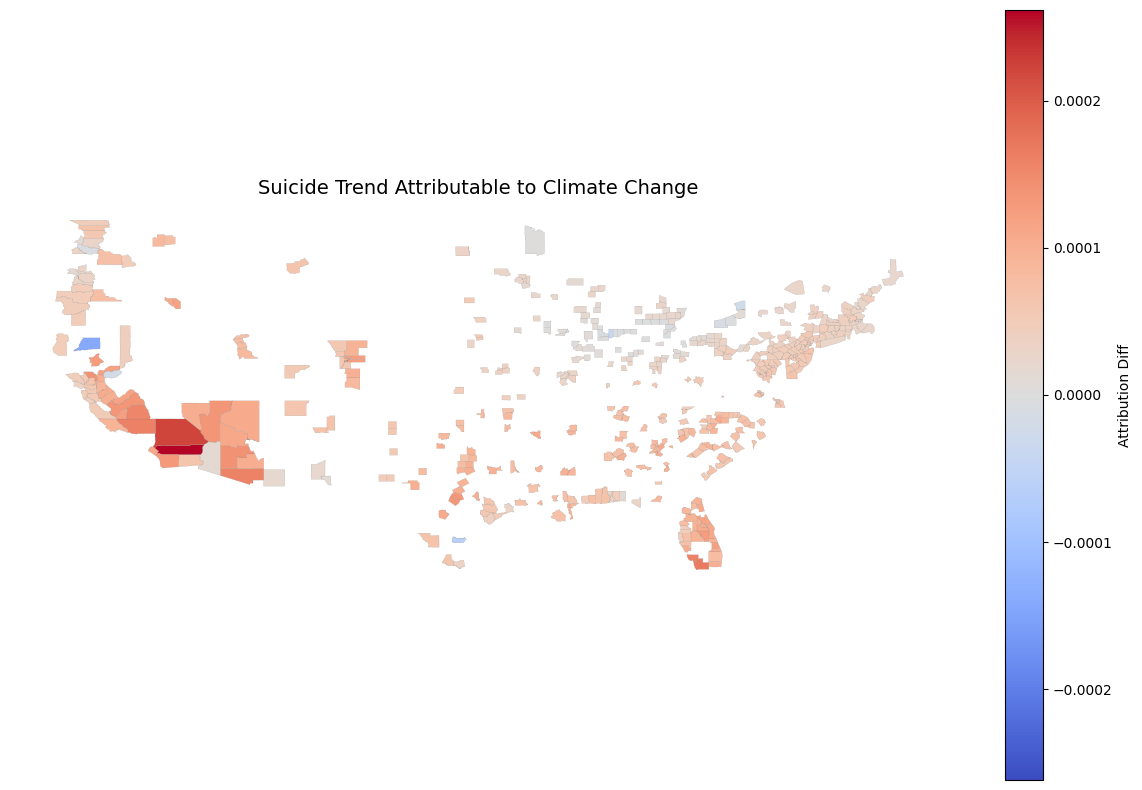

In [63]:
plot_county_map(full_coverage, 'diff_attributable_climate',
                title='Suicide Trend Attributable to Climate Change',
                legend_title='Attribution Diff', cmap='coolwarm')

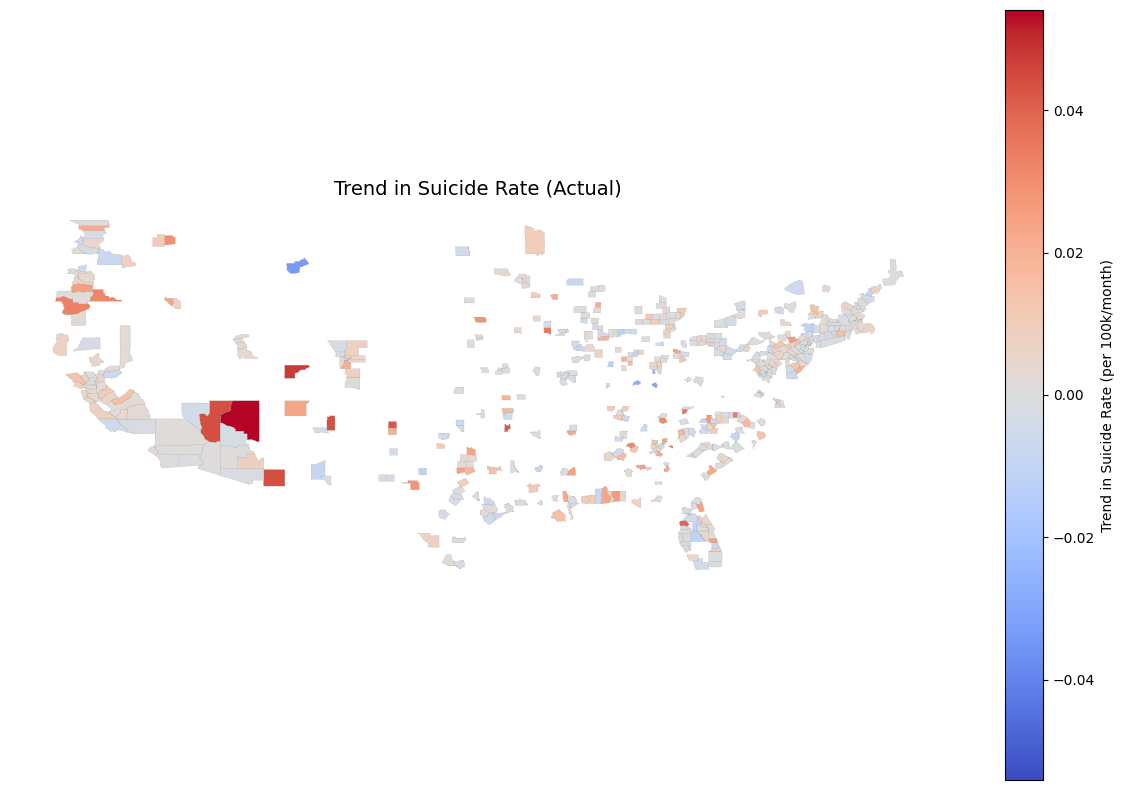

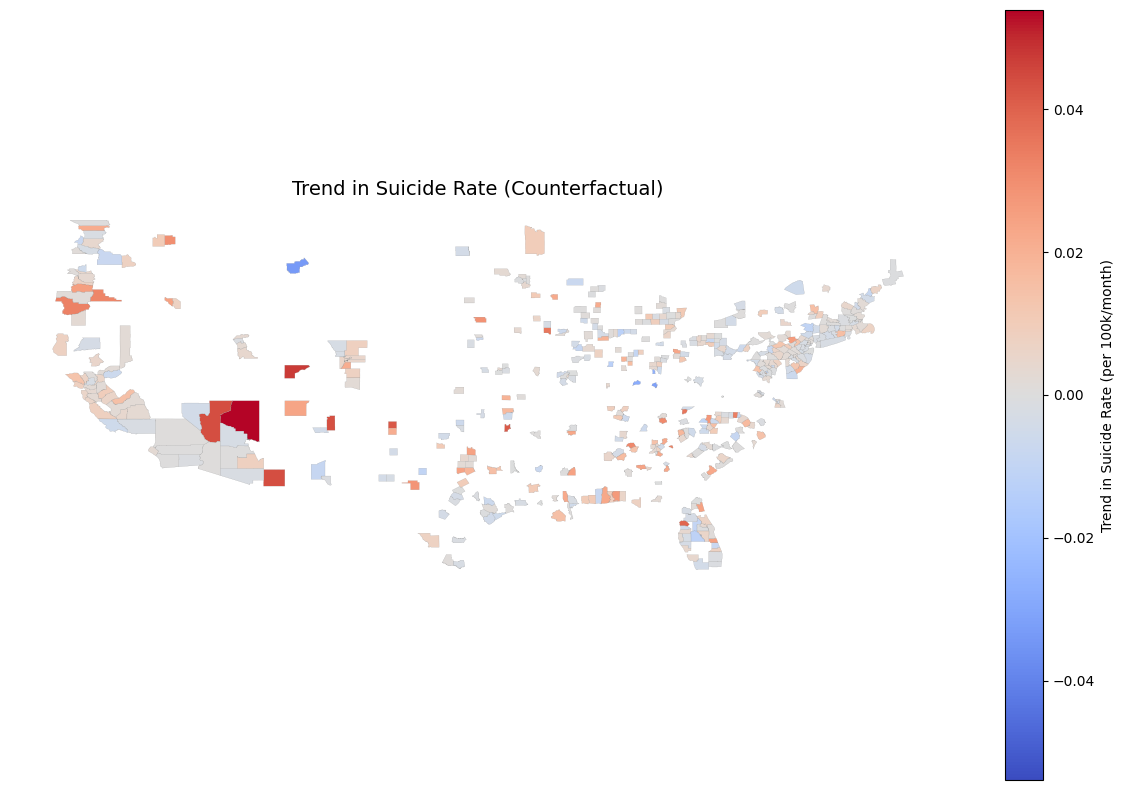

In [187]:
plot_county_map(full_coverage, 'actual_trend',
                title='Trend in Suicide Rate (Actual)',
                legend_title='Trend in Suicide Rate (per 100k/month)')

plot_county_map(full_coverage, 'cf_trend',
                title='Trend in Suicide Rate (Counterfactual)',
                legend_title='Trend in Suicide Rate (per 100k/month)')


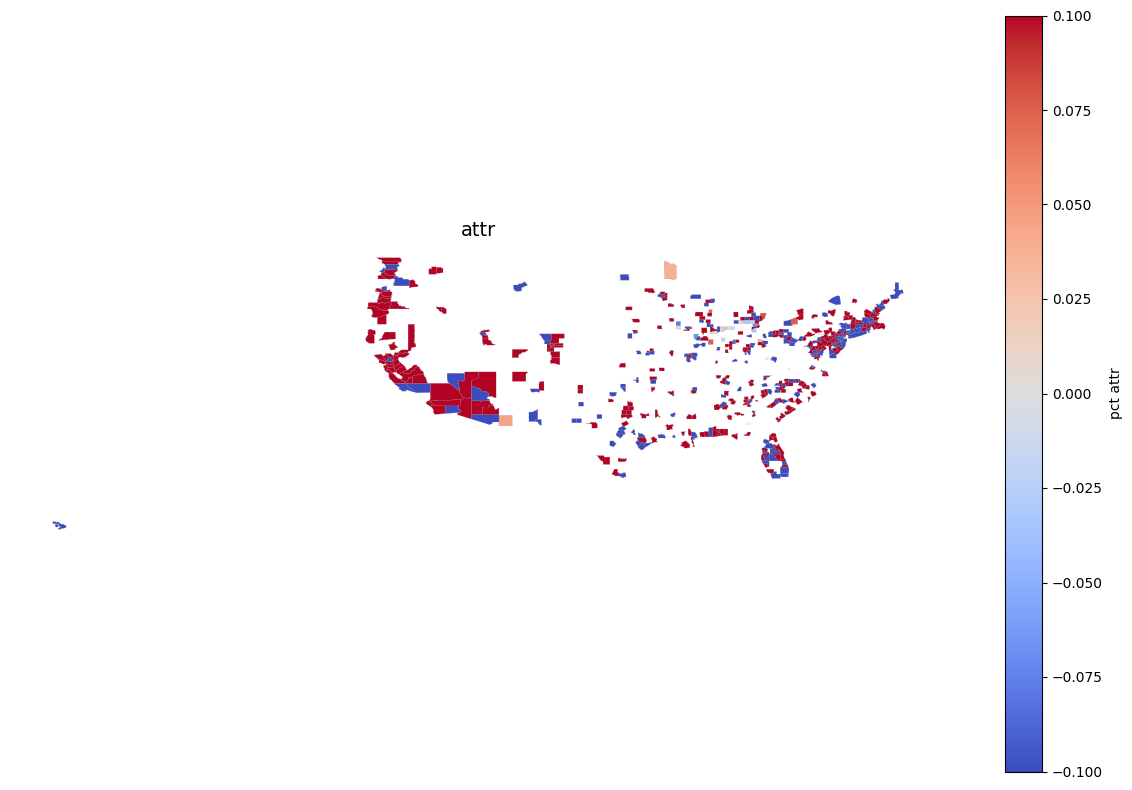

In [45]:
plot_county_map(full_coverage, 'pct_attributable_climate',
                title='attr',
                legend_title='pct attr')

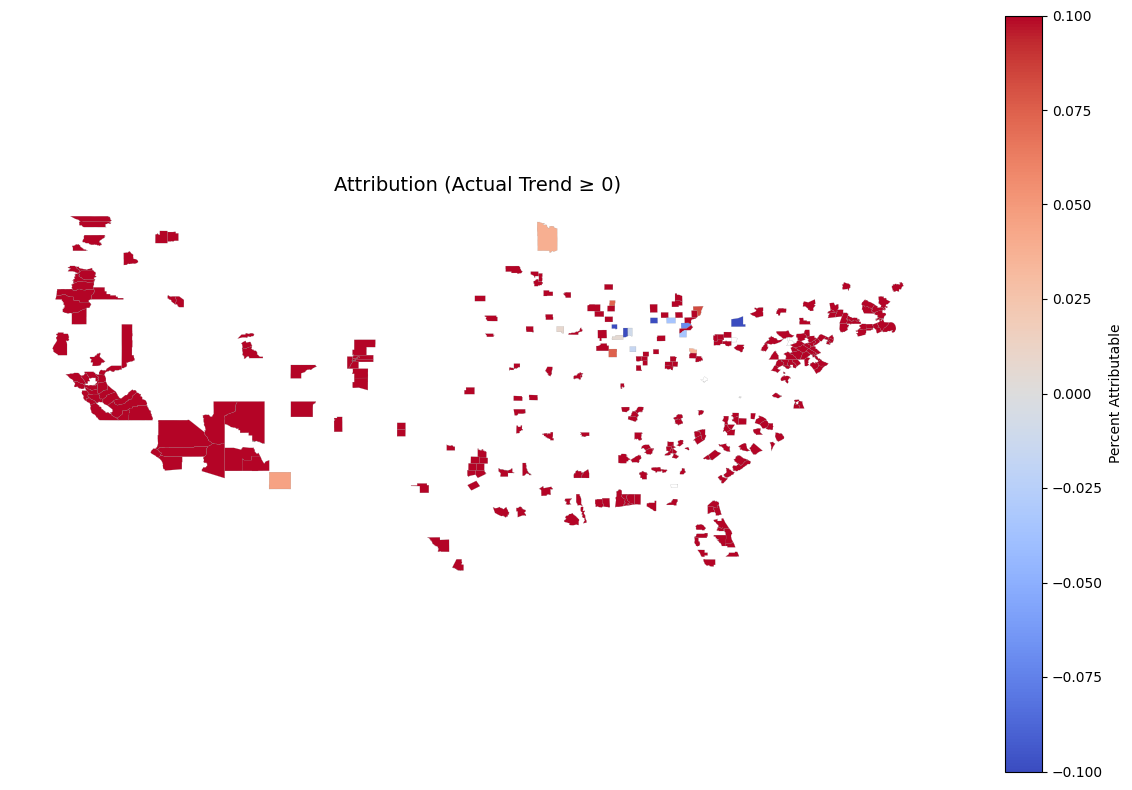

In [51]:
plot_county_map(
    full_coverage[full_coverage['actual_trend'] >= 0],
    column='pct_attributable_climate',
    title='Attribution (Actual Trend ≥ 0)',
    legend_title='Percent Attributable'
)


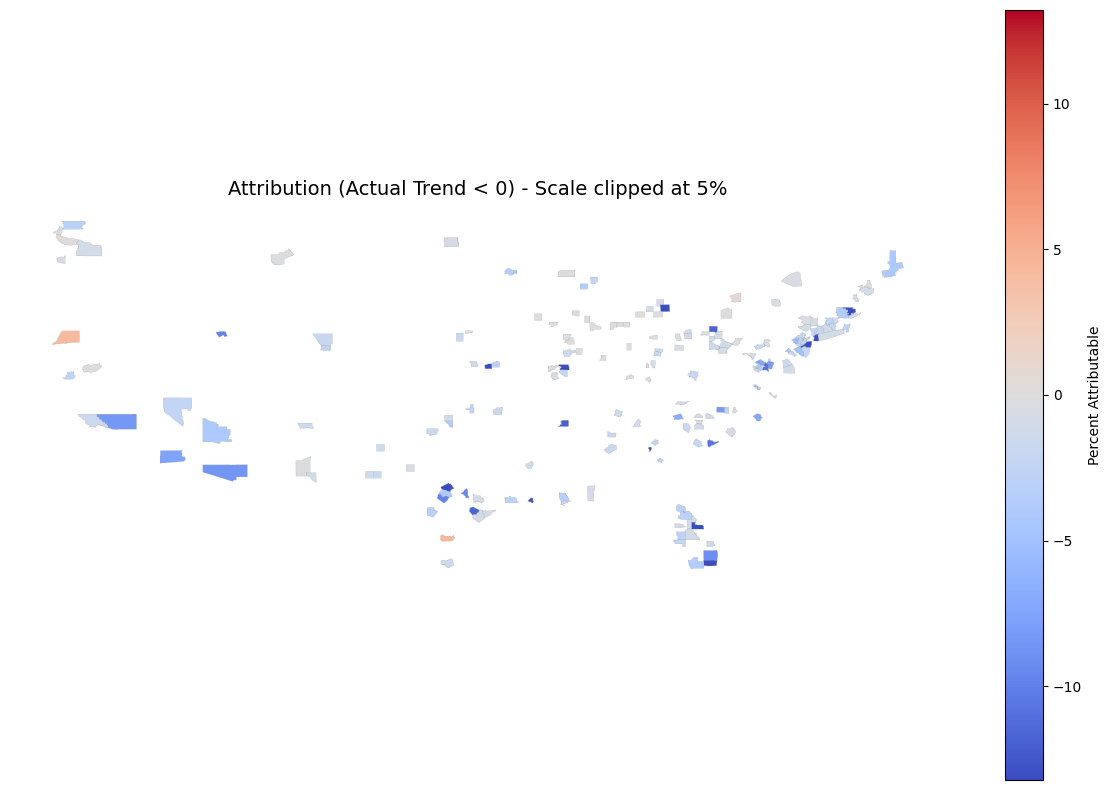

In [64]:
plot_county_map(
    full_coverage[full_coverage['actual_trend'] < 0],
    column='pct_attributable_climate',
    title='Attribution (Actual Trend < 0) - Scale clipped at 5%',
    legend_title='Percent Attributable',
    clip_pct = 5
)


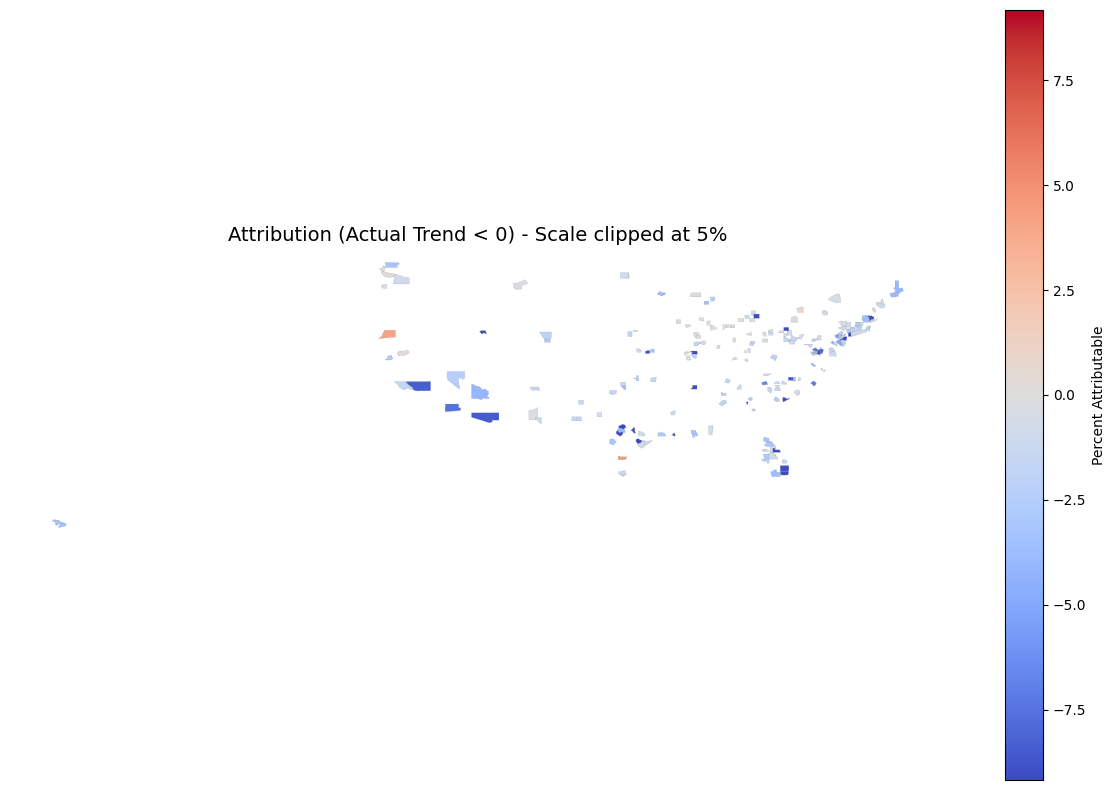

In [58]:
plot_county_map(
    full_coverage[full_coverage['actual_trend'] < 0],
    column='pct_attributable_climate',
    title='Attribution (Actual Trend < 0) - Scale clipped at 5%',
    legend_title='Percent Attributable',
    clip_pct = 10
)


/tmp/ipykernel_3227438/1464799647.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bin')


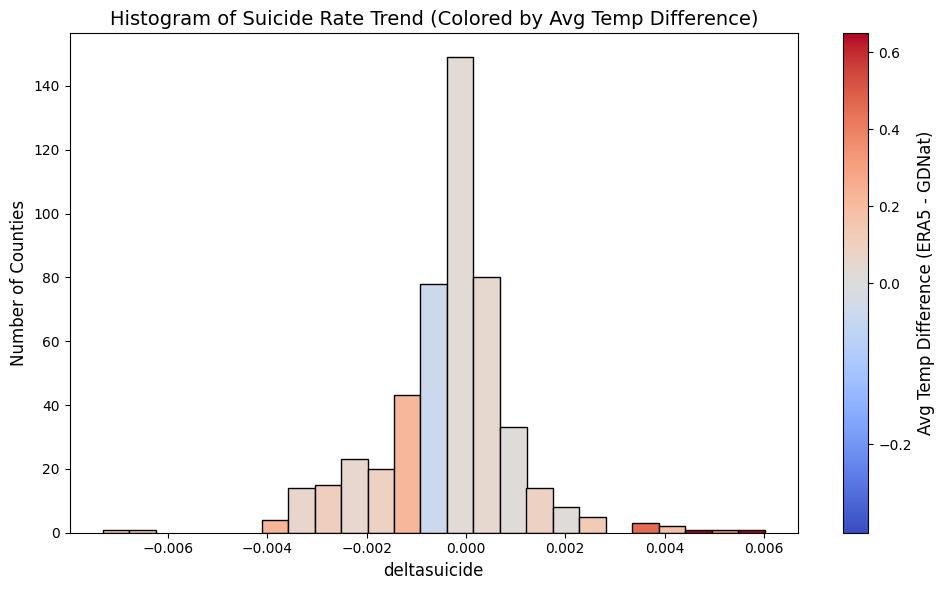

In [36]:
# Create bins for deltasuicide
bins = np.linspace(full_coverage_merged['deltasuicide'].min(), full_coverage_merged['deltasuicide'].max(), 30)
full_coverage_merged['bin'] = pd.cut(full_coverage_merged['deltasuicide'], bins)

# Group by bin to count and average temp diff
hist_data = (
    full_coverage_merged
    .groupby('bin')
    .agg(
        count=('deltasuicide', 'count'),
        mean_temp_diff=('diff_temp', 'mean')
    )
    .dropna()
    .reset_index()
)

# Bin centers and bar width
bin_centers = [b.mid for b in hist_data['bin']]
bar_width = np.diff(bins)[0]

# Normalize temp diff for color mapping

# Compute 1st and 99th percentiles of diff_temp
vmin = full_coverage_merged['diff_temp'].quantile(0.05)
vmax = full_coverage_merged['diff_temp'].quantile(0.95)

# Create a diverging norm centered at zero
norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
colors = [coolwarm(norm(val)) for val in hist_data['mean_temp_diff']]

# Plot colored histogram
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(bin_centers, hist_data['count'], width=bar_width, color=colors, edgecolor='black')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=coolwarm, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Avg Temp Difference (ERA5 - GDNat)", fontsize=12)

# Final formatting
ax.set_title("Histogram of Suicide Rate Trend (Colored by Avg Temp Difference)", fontsize=14)
ax.set_xlabel("deltasuicide", fontsize=12)
ax.set_ylabel("Number of Counties", fontsize=12)

plt.tight_layout()
plt.show()


In [37]:
attribution_output_data

,year,month,order_1_avg.x,date.x,y_hat_era5,poly_id,y_hat_gdnat,NAME,NAMELSAD,ID_1,ID_2,date.y,order_1_avg.y,diff_suicide,diff_temp
0,1980,1,9.528785,1980-01-01,0.132186,1001,0.132119,Autauga,Autauga County,1.0,1.0,1980-01-01,9.979710,0.000068,-0.450925
1,1980,2,7.258004,1980-02-01,0.097429,1001,0.096176,Autauga,Autauga County,1.0,1.0,1980-02-01,7.288643,0.001253,-0.030640
2,1980,3,12.688986,1980-03-01,0.140456,1001,0.147207,Autauga,Autauga County,1.0,1.0,1980-03-01,13.357411,-0.006752,-0.668425
3,1980,4,16.842135,1980-04-01,0.160386,1001,0.164409,Autauga,Autauga County,1.0,1.0,1980-04-01,17.411411,-0.004022,-0.569276
4,1980,5,22.053573,1980-05-01,0.168159,1001,0.168080,Autauga,Autauga County,1.0,1.0,1980-05-01,22.256600,0.000079,-0.203027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968395,2004,8,27.617651,2004-08-01,0.331925,78030,0.323857,St. Thomas,St. Thomas Island,78.0,30.0,2004-08-01,27.220027,0.008068,0.397624
968396,2004,9,27.267894,2004-09-01,0.336256,78030,0.325469,St. Thomas,St. Thomas Island,78.0,30.0,2004-09-01,26.725004,0.010787,0.542890
968397,2004,10,26.952252,2004-10-01,0.332331,78030,0.322878,St. Thomas,St. Thomas Island,78.0,30.0,2004-10-01,26.390567,0.009453,0.561685
968398,2004,11,26.055954,2004-11-01,0.320676,78030,0.310561,St. Thomas,St. Thomas Island,78.0,30.0,2004-11-01,25.428801,0.010116,0.627152


## Histograms

In [108]:
def plot_hist(ax, data, title, crop_pct=0, bins=None, crop_side="both"):
    """
    Plot histogram of a variable with optional outlier cropping.
    Highlights left of zero as blue, right as red.

    Parameters:
        ax: matplotlib axis to plot on.
        data: series or array-like data.
        title: plot title.
        crop_pct: percent to crop from tails (default 0 = no cropping).
        bins: number of histogram bins or binning strategy (default None uses matplotlib default).
        crop_side: "both" (default), "top", or "bottom" to crop from respective tail(s).
    """
    # Clean data: remove NaN and infinite
    data = data[np.isfinite(data)]

    # Crop extreme values as specified
    if crop_pct > 0:
        if crop_side == "both":
            lower = data.quantile(crop_pct / 100)
            upper = data.quantile(1 - crop_pct / 100)
            data = data[(data >= lower) & (data <= upper)]
        elif crop_side == "top":
            upper = data.quantile(1 - crop_pct / 100)
            data = data[data <= upper]
        elif crop_side == "bottom":
            lower = data.quantile(crop_pct / 100)
            data = data[data >= lower]
        else:
            raise ValueError("crop_side must be 'both', 'top', or 'bottom'")

    # Handle empty or flat data gracefully
    if len(data) == 0 or data.min() == data.max():
        ax.set_title(f"{title}\n(No usable data)")
        ax.axis('off')
        return

    # Plot histogram with custom bins or default
    counts, bins_arr, patches = ax.hist(data, bins=bins, edgecolor='black')
    for patch, bin_edge in zip(patches, bins_arr[:-1]):
        patch.set_facecolor('blue' if bin_edge < 0 else 'red')

    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('% Attributable to Climate Change')
    ax.set_ylabel('Number of Counties')
    ax.text(
        0.98, 0.95, f'n = {len(data)}',
        ha='right', va='top',
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray')
    )


In [98]:
# Split data
neg_trend = full_coverage[full_coverage['actual_trend'] < 0]
pos_trend = full_coverage[full_coverage['actual_trend'] >= 0]


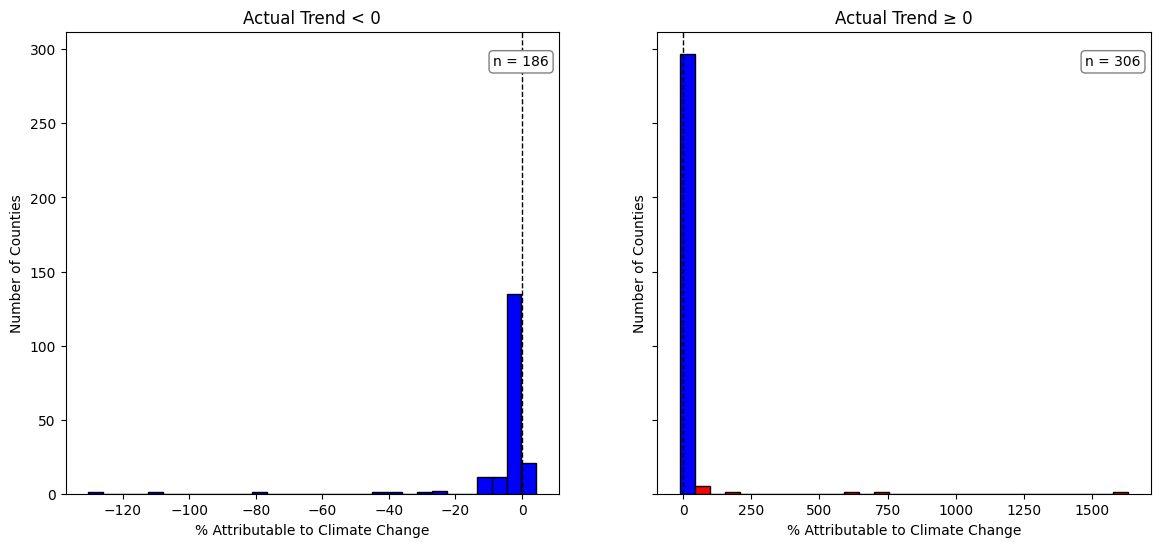

In [ ]:

# Set up figure
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot both histograms using function
plot_hist(axs[0], neg_trend['pct_attributable_climate'], 'Actual Trend < 0')
plot_hist(axs[1], pos_trend['pct_attributable_climate'], 'Actual Trend ≥ 0')

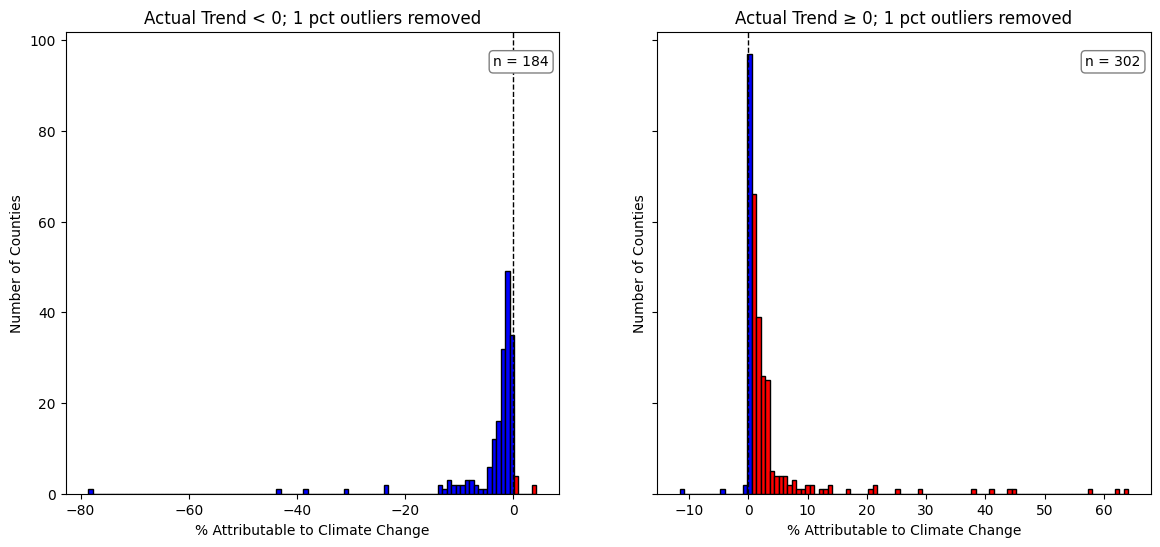

In [186]:
# Set up figure
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot both histograms using function
plot_hist(axs[0], neg_trend['pct_attributable_climate'], 'Actual Trend < 0; 1 pct outliers removed', crop_pct=1, crop_side="bottom", bins=100)
plot_hist(axs[1], pos_trend['pct_attributable_climate'], 'Actual Trend ≥ 0; 1 pct outliers removed', crop_pct=1, crop_side="top", bins=100)

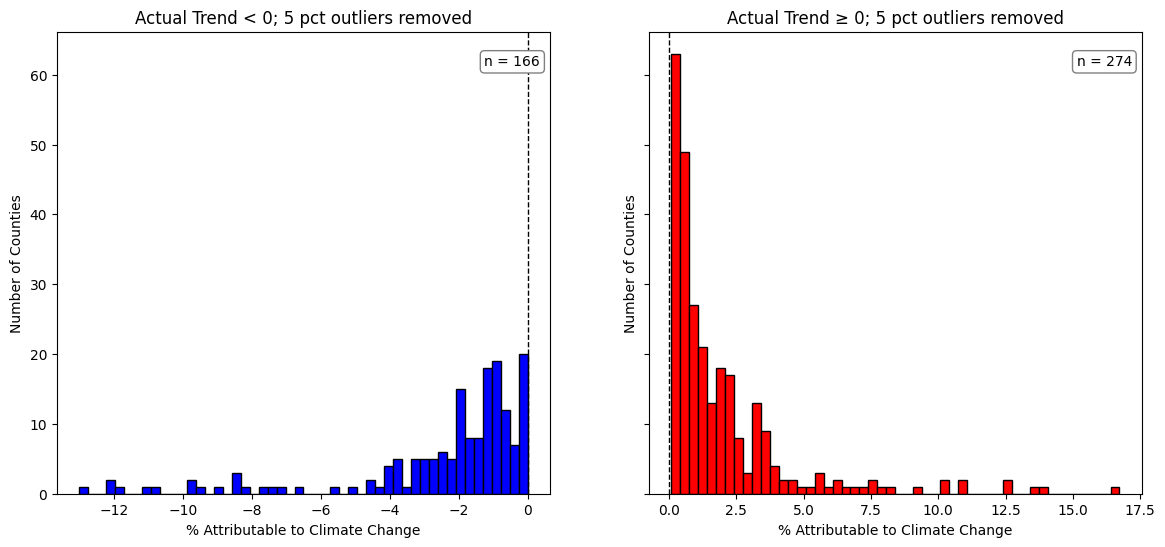

In [106]:
# Set up figure
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot both histograms using function
plot_hist(axs[0], neg_trend['pct_attributable_climate'], 'Actual Trend < 0; 5 pct outliers removed', crop_pct=5, bins = 50)
plot_hist(axs[1], pos_trend['pct_attributable_climate'], 'Actual Trend ≥ 0; 5 pct outliers removed', crop_pct=5, bins = 50)

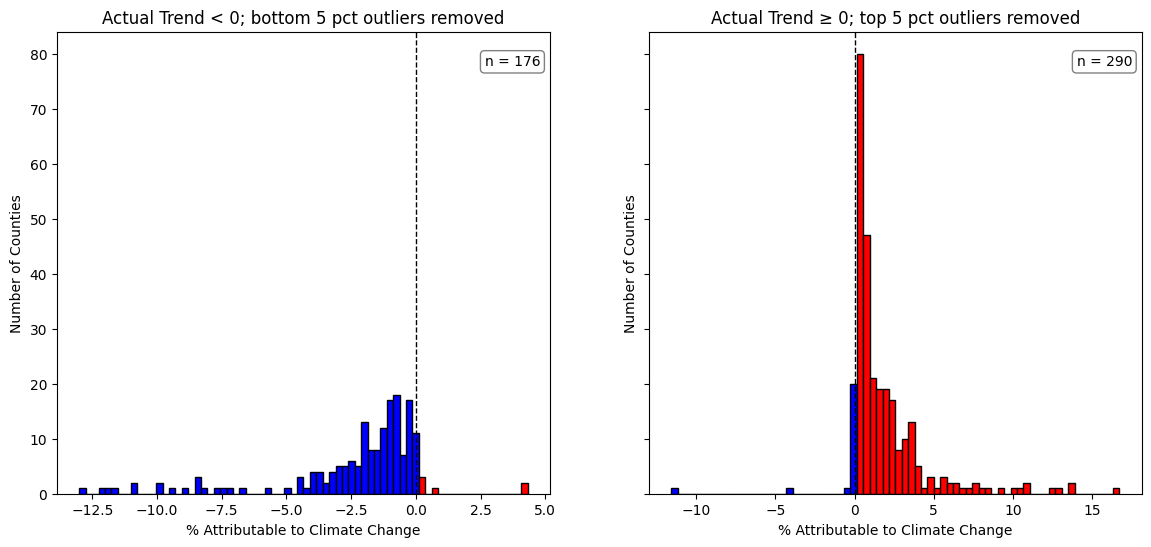

In [110]:
# Set up figure
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot both histograms using function
plot_hist(axs[0], neg_trend['pct_attributable_climate'], 'Actual Trend < 0; bottom 5 pct outliers removed', crop_pct=5, bins = 70, crop_side="bottom")
plot_hist(axs[1], pos_trend['pct_attributable_climate'], 'Actual Trend ≥ 0; top 5 pct outliers removed', crop_pct=5, bins = 70, crop_side="top")

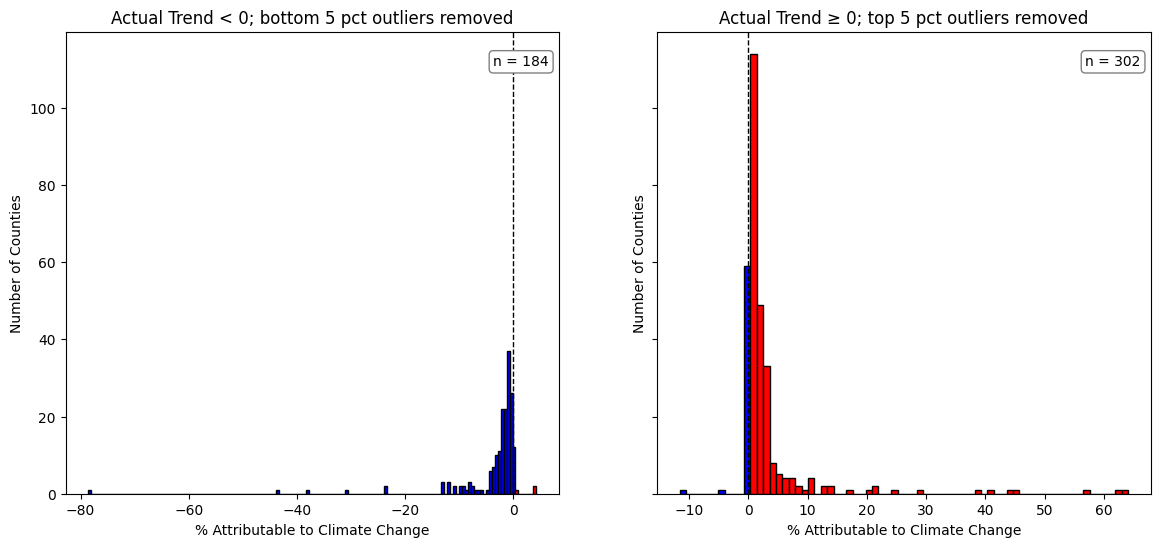

In [112]:
# Set up figure
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot both histograms using function
plot_hist(axs[0], neg_trend['pct_attributable_climate'], 'Actual Trend < 0; bottom 5 pct outliers removed', crop_pct=1, bins = 150, crop_side="bottom")
plot_hist(axs[1], pos_trend['pct_attributable_climate'], 'Actual Trend ≥ 0; top 5 pct outliers removed', crop_pct=1, bins = 70, crop_side="top")

## Line plots

In [66]:
from difflib import get_close_matches

def plot_suicide_trends_by_namelsad(namelsad_input, merged_data, county_trends):
    """
    Plot actual and counterfactual suicide rates for a county (fuzzy NAMELSAD match),
    with precomputed trend lines from county_trends. Time = month level (2000–2004).
    """

    namelsad_input = namelsad_input.strip().lower()
    all_names = merged_data['NAMELSAD'].dropna().unique()
    all_names_lower = [name.lower() for name in all_names]
    matches = get_close_matches(namelsad_input, all_names_lower, n=1, cutoff=0.6)
    if not matches:
        print(f"No close match found for '{namelsad_input}'.")
        return

    matched_name = all_names[all_names_lower.index(matches[0])]
    print(f"Matched input to: {matched_name}")

    df = merged_data[merged_data['NAMELSAD'].str.lower() == matched_name.lower()].copy()
    df = df[(df['year'] >= 2000) & (df['year'] <= 2004)].copy()
    if df.empty:
        print(f"No data from 2000–2004 for '{matched_name}'")
        return

    location_fips = df['fips'].iloc[0]
    trend_row = county_trends[county_trends['fips'] == location_fips]
    if trend_row.empty:
        print(f"No trend data found for FIPS {location_fips}")
        return

    df = df.sort_values(['year', 'month'])
    df['time_index'] = (df['year'] - 2000) * 12 + (df['month'] - 1)
    actual_slope = trend_row['actual_trend'].values[0]
    cf_slope = trend_row['cf_trend'].values[0]
    actual_intercept = df['suiciderate'].iloc[0]
    cf_intercept = df['suiciderate_cf'].iloc[0]
    df['actual_trend_line'] = actual_intercept + actual_slope * df['time_index']
    df['cf_trend_line'] = cf_intercept + cf_slope * df['time_index']
    df['plot_date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))

    # Reverted colors
    actual_color = 'red'
    cf_color = 'blue'

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['plot_date'], df['suiciderate'], label='Actual Suicide Rate',
            color=actual_color, marker='o', linewidth=1, alpha=0.6)
    ax.plot(df['plot_date'], df['suiciderate_cf'], label='Counterfactual Suicide Rate',
            color=cf_color, marker='o', linewidth=1, alpha=0.6)
    ax.plot(df['plot_date'], df['actual_trend_line'], label='Actual Trend Line',
            color=actual_color, linestyle='--', linewidth=.8, alpha=0.7)
    ax.plot(df['plot_date'], df['cf_trend_line'], label='Counterfactual Trend Line',
            color=cf_color, linestyle='--', linewidth=.8, alpha=0.7)

    ax.set_title(f"Suicide Rates and Trends\n{matched_name}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Matched input to: Travis County


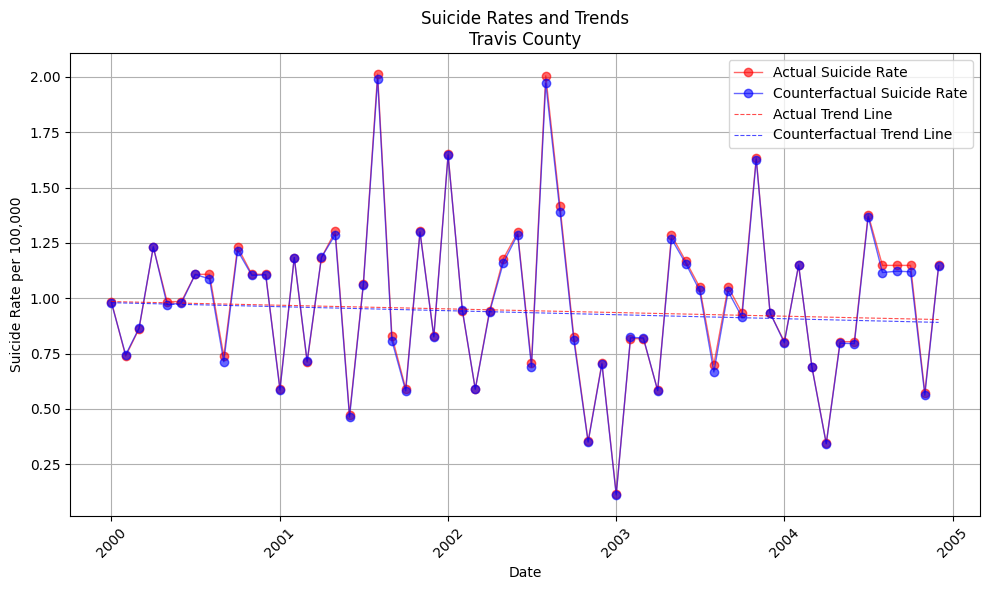

In [67]:
plot_suicide_trends_by_namelsad("Travis", merged_data, county_trends) 



Plotting for county: Florence County (FIPS: 45041)
  % Attributable to Climate Change: 1632.35%
  Actual Suicide Rate Trend: 0.0000
  Counterfactual Suicide Rate Trend: -0.0001
Matched input to: Florence County


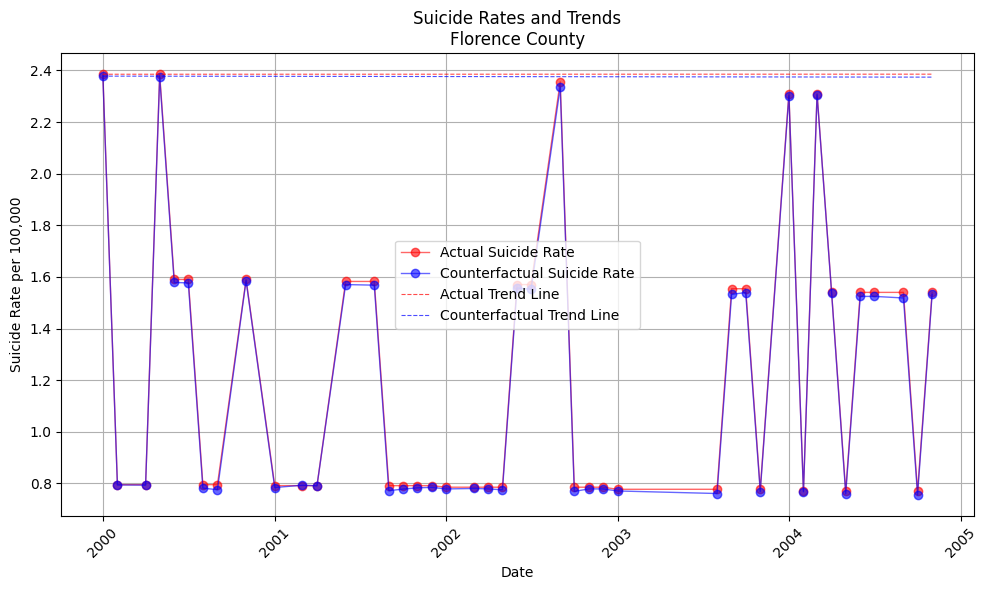


Plotting for county: Clay County (FIPS: 29047)
  % Attributable to Climate Change: 723.50%
  Actual Suicide Rate Trend: 0.0000
  Counterfactual Suicide Rate Trend: -0.0000
Matched input to: Clay County


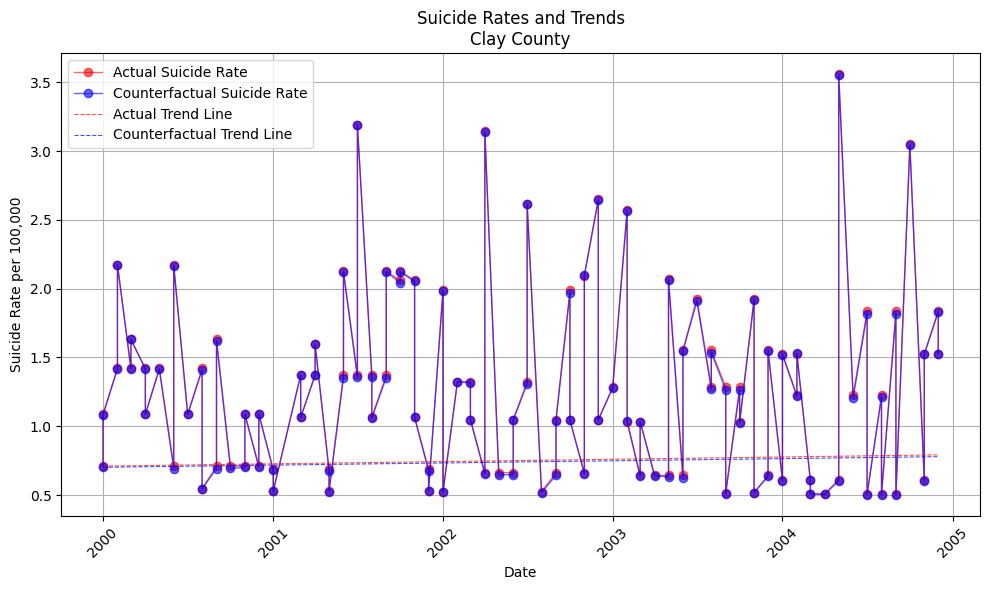


Plotting for county: Duval County (FIPS: 12031)
  % Attributable to Climate Change: 629.67%
  Actual Suicide Rate Trend: 0.0000
  Counterfactual Suicide Rate Trend: -0.0001
Matched input to: Duval County


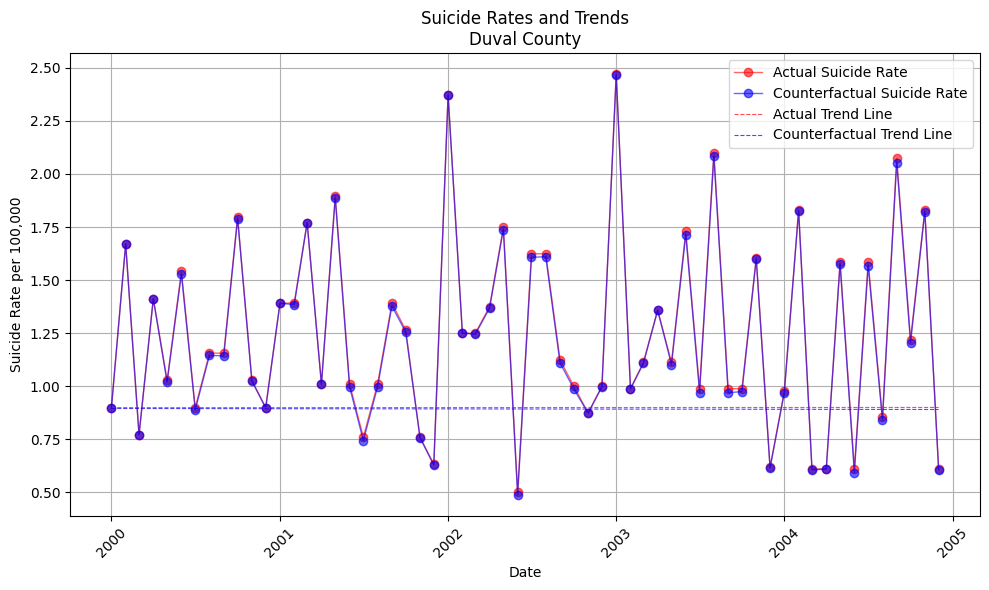


Plotting for county: Caddo Parish (FIPS: 22017)
  % Attributable to Climate Change: 173.76%
  Actual Suicide Rate Trend: 0.0000
  Counterfactual Suicide Rate Trend: -0.0000
Matched input to: Caddo Parish


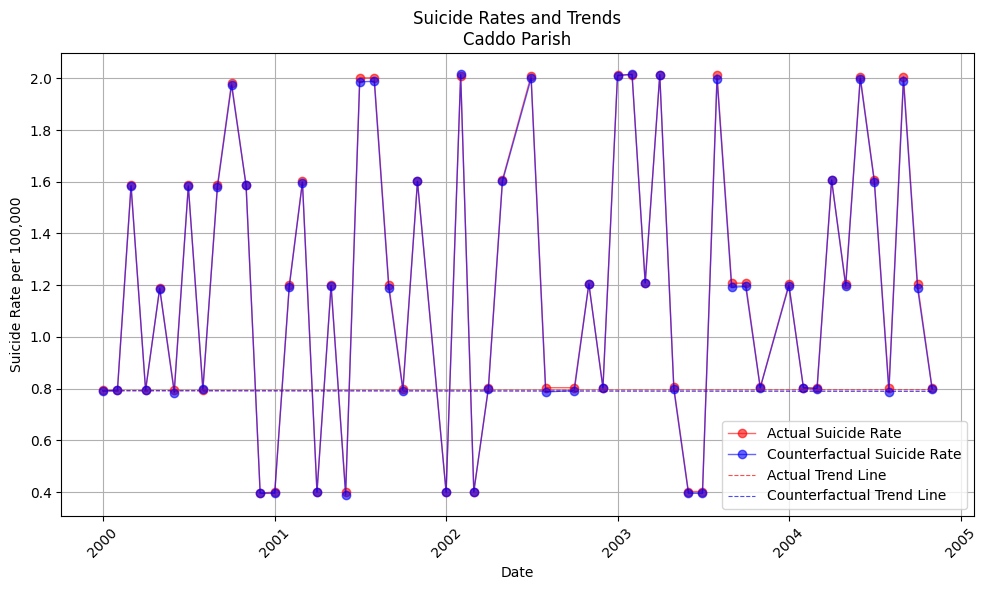

In [71]:

# Filter out invalid pct_attributable_climate values (NaN or infinite)
valid_trends = county_trends[
    county_trends['pct_attributable_climate'].notna() &
    np.isfinite(county_trends['pct_attributable_climate'])
]

# Sort descending and pick top 4 counties
top4 = valid_trends.sort_values('pct_attributable_climate', ascending=False).head(4)

# Map FIPS to NAMELSAD (county names) from merged_data assuming unique mapping
fips_to_namelsad = merged_data.drop_duplicates('fips').set_index('fips')['NAMELSAD']

top4['NAMELSAD'] = top4['fips'].map(fips_to_namelsad)

# Loop over top 4, print info, and plot
for idx, row in top4.iterrows():
    print(f"\nPlotting for county: {row['NAMELSAD']} (FIPS: {row['fips']})")
    print(f"  % Attributable to Climate Change: {row['pct_attributable_climate']:.2f}%")
    print(f"  Actual Suicide Rate Trend: {row['actual_trend']:.4f}")
    print(f"  Counterfactual Suicide Rate Trend: {row['cf_trend']:.4f}")
    
    plot_suicide_trends_by_namelsad(row['NAMELSAD'], merged_data, county_trends)



Plotting for county: Lafayette Parish (FIPS: 22055)
Matched input to: Lafayette Parish


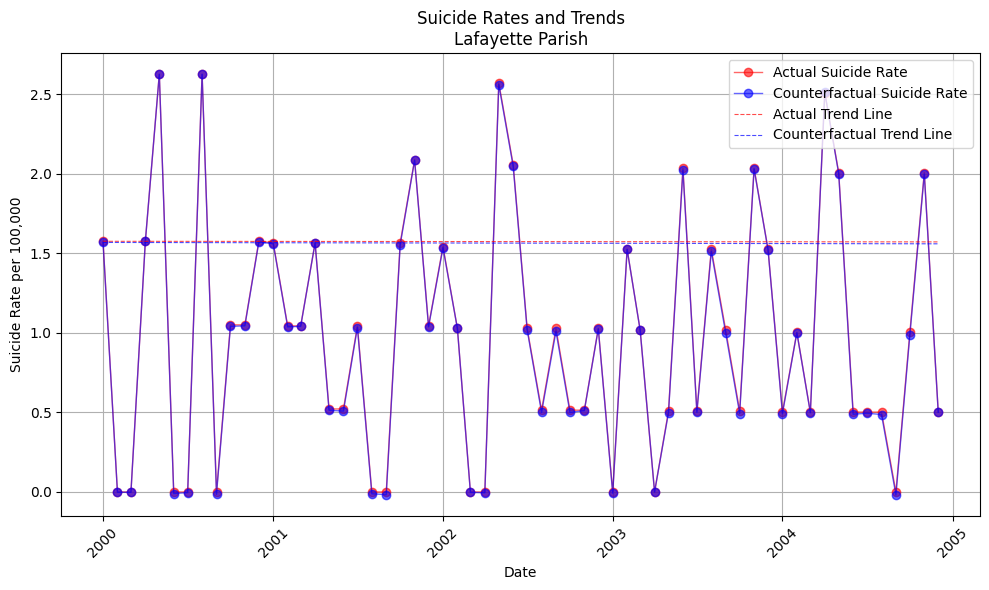


Plotting for county: Clayton County (FIPS: 13063)
Matched input to: Clayton County


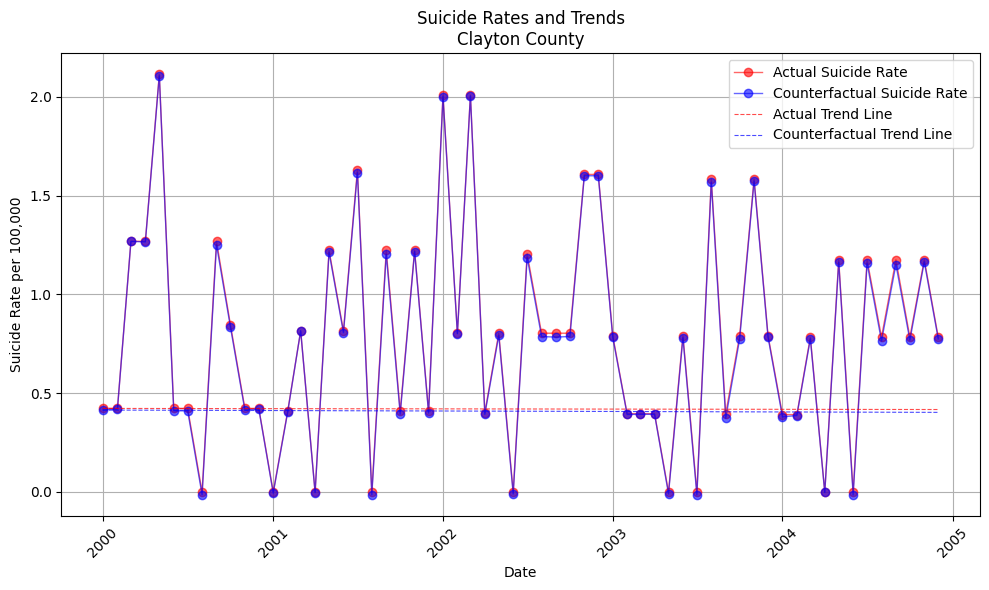


Plotting for county: Johnson County (FIPS: 20091)
Matched input to: Johnson County


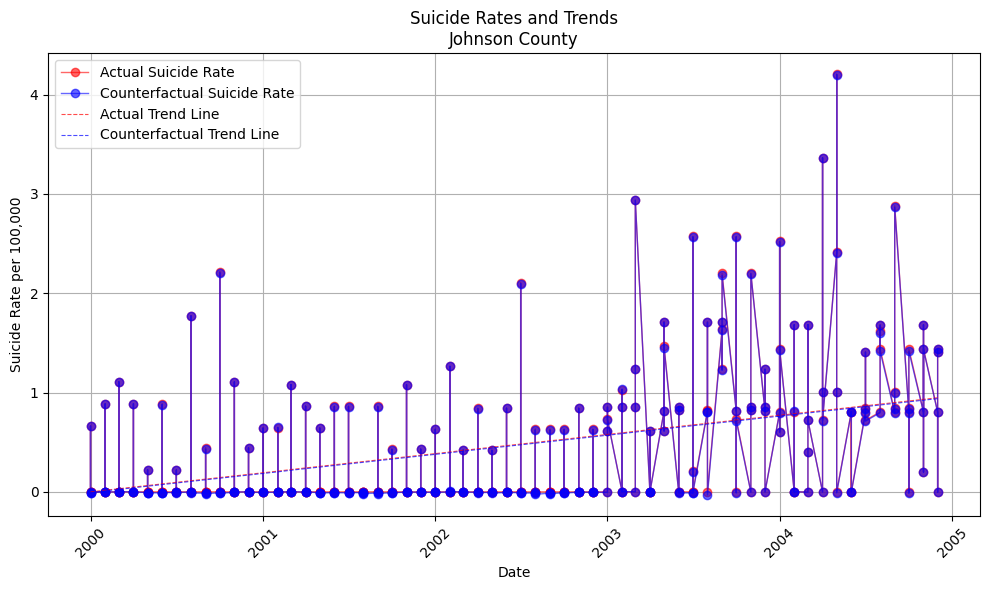


Plotting for county: Middlesex County (FIPS: 25017)
Matched input to: Middlesex County


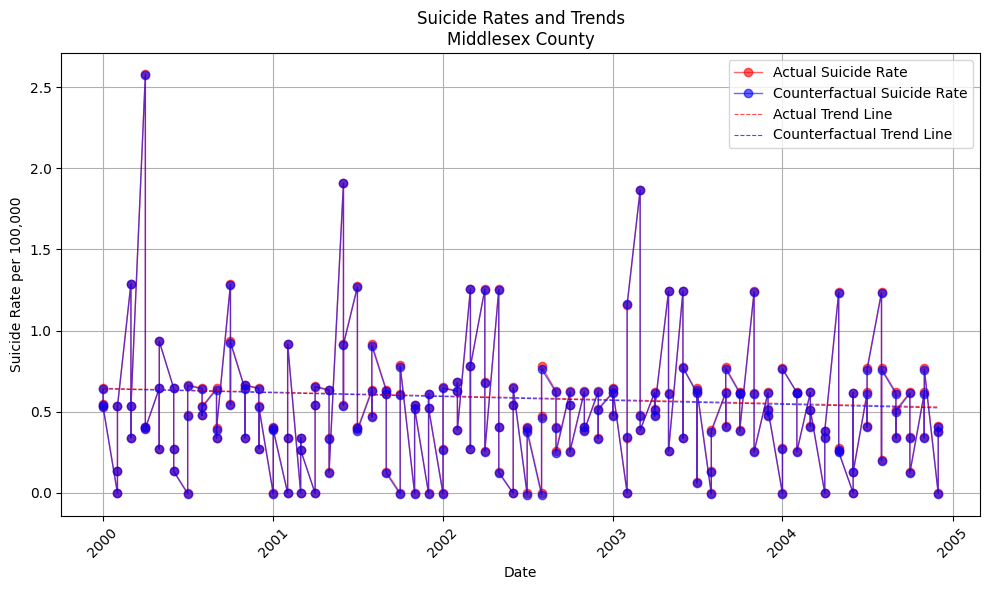

In [ ]:
# Sort counties by ascending % attributable climate change (lowest first)
lowest4 = county_trends.sort_values('pct_attributable_climate', ascending=True).head(4)

# Map FIPS to NAMELSAD
fips_to_namelsad = merged_data.drop_duplicates('fips').set_index('fips')['NAMELSAD']

lowest4['NAMELSAD'] = lowest4['fips'].map(fips_to_namelsad)

# Plot for each
for idx, row in lowest4.iterrows():
    print(f"\nPlotting for county: {row['NAMELSAD']} (FIPS: {row['fips']})")
    plot_suicide_trends_by_namelsad(row['NAMELSAD'], merged_data, county_trends)

# some of the plots here are so weird, check if this is a plotting error or an error with the data 

In [82]:
def plot_all_counties_with_weighted_average_and_trends(merged_data):
    # Filter 2000-2004
    df = merged_data[(merged_data['year'] >= 2000) & (merged_data['year'] <= 2004)].copy()

    # Create a datetime index for plotting
    df['plot_date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))

    # Sort by date for plotting
    df = df.sort_values(['fips', 'year', 'month'])

    # Get unique dates in order
    dates = sorted(df['plot_date'].unique())

    # Convert dates to ordinal for regression
    dates_ordinal = [d.toordinal() for d in dates]

    # Pivot so rows = date, columns = fips, values = suicide rate
    actual_pivot = df.pivot(index='plot_date', columns='fips', values='suiciderate')
    cf_pivot = df.pivot(index='plot_date', columns='fips', values='suiciderate_cf')

    # Get populations per county (take mean over time)
    pop = df.groupby('fips')['population'].mean()

    # Normalize population weights to sum to 1
    weights = pop / pop.sum()

    # Calculate weighted averages at each time
    weighted_actual = actual_pivot.mul(weights, axis=1).sum(axis=1)
    weighted_cf = cf_pivot.mul(weights, axis=1).sum(axis=1)

    # Regression for actual weighted average
    X = sm.add_constant(dates_ordinal)
    actual_model = sm.OLS(weighted_actual.values, X).fit()
    actual_trend = actual_model.predict(X)

    # Regression for counterfactual weighted average
    cf_model = sm.OLS(weighted_cf.values, X).fit()
    cf_trend = cf_model.predict(X)

    # Plot Actual Suicide Rates: all counties in light grey, weighted avg in red
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in actual_pivot.columns:
        ax.plot(dates, actual_pivot[col], color='lightgrey', linewidth=0.7, alpha=0.5)
    ax.plot(dates, weighted_actual, color='red', linewidth=2, label='Pop-weighted Actual Avg')
    ax.set_title('Actual Suicide Rates: All Counties (grey) and Pop-weighted Avg (red)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot Counterfactual Suicide Rates: all counties in light grey, weighted avg in blue
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in cf_pivot.columns:
        ax.plot(dates, cf_pivot[col], color='lightgrey', linewidth=0.7, alpha=0.5)
    ax.plot(dates, weighted_cf, color='blue', linewidth=2, label='Pop-weighted Counterfactual Avg')
    ax.set_title('Counterfactual Suicide Rates: All Counties (grey) and Pop-weighted Avg (blue)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot weighted averages only (actual vs counterfactual) with trend lines
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(dates, weighted_actual, color='red', linewidth=2, label='Pop-weighted Actual Avg')
    ax.plot(dates, weighted_cf, color='blue', linewidth=2, label='Pop-weighted Counterfactual Avg')

    # Trend lines (dashed)
    ax.plot(dates, actual_trend, color='red', linestyle='--', linewidth=2, label='Actual Trend Line')
    ax.plot(dates, cf_trend, color='blue', linestyle='--', linewidth=2, label='Counterfactual Trend Line')

    ax.set_title('Population-weighted Average Suicide Rates with Trend Lines')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


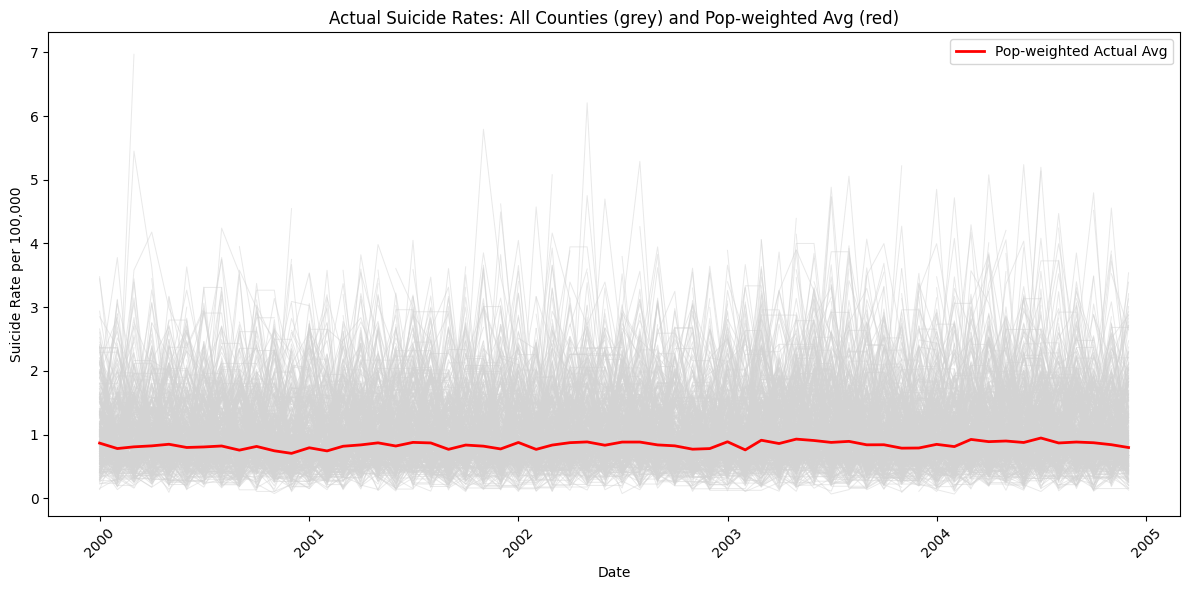

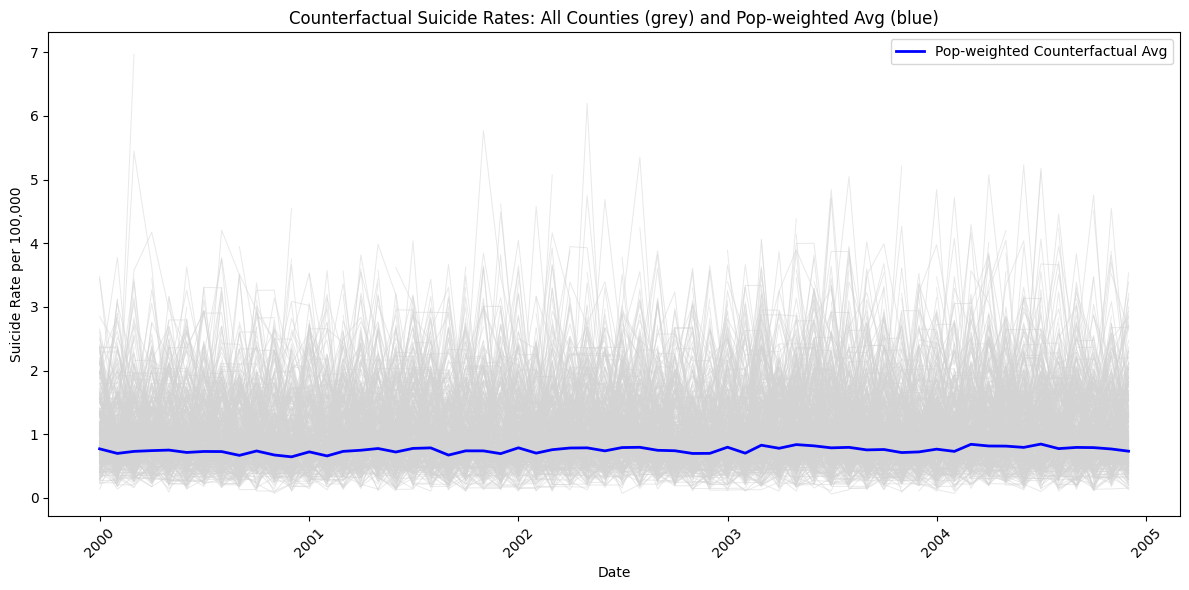

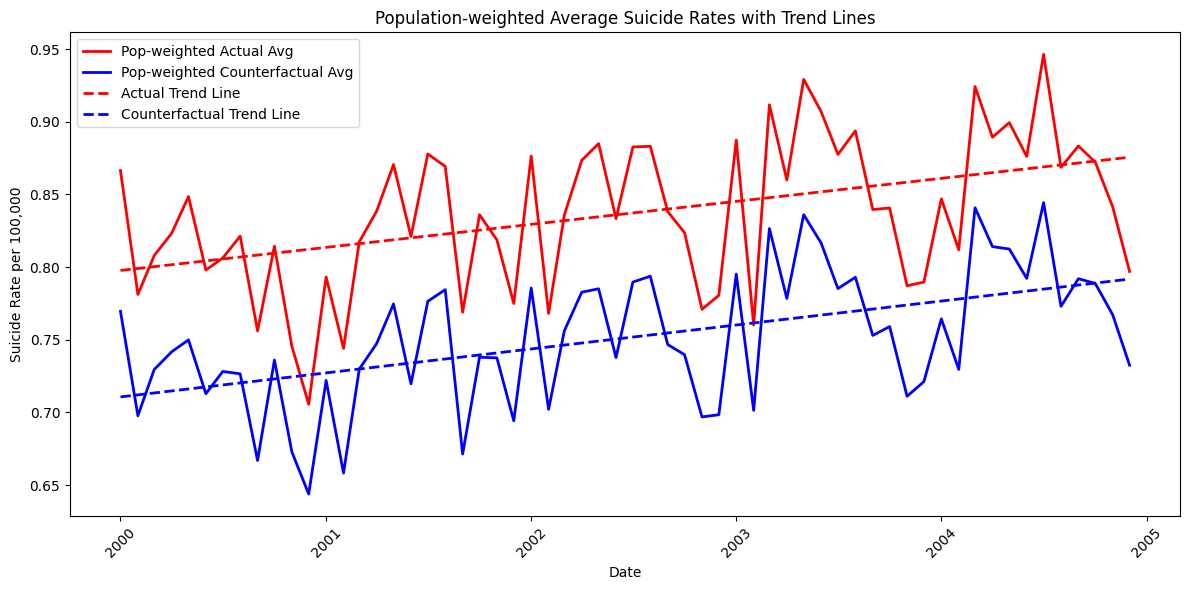

In [79]:
plot_all_counties_with_weighted_average_and_trends(merged_data)

In [83]:
def plot_all_counties_with_weighted_average_and_trends_intermonthweight(merged_data):
    # Filter 2000-2004
    df = merged_data[(merged_data['year'] >= 2000) & (merged_data['year'] <= 2004)].copy()

    # Create a datetime index for plotting
    df['plot_date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))

    # Sort by date and fips
    df = df.sort_values(['plot_date', 'fips'])

    # Pivot so rows = date, columns = fips, values = suicide rate
    actual_pivot = df.pivot(index='plot_date', columns='fips', values='suiciderate')
    cf_pivot = df.pivot(index='plot_date', columns='fips', values='suiciderate_cf')

    # Create a DataFrame of population per county per date
    pop_pivot = df.pivot(index='plot_date', columns='fips', values='population')

    # Calculate weights per month (normalize populations so sum to 1 per row/month)
    weights = pop_pivot.div(pop_pivot.sum(axis=1), axis=0)

    # Calculate weighted averages at each time point (date)
    weighted_actual = (actual_pivot * weights).sum(axis=1)
    weighted_cf = (cf_pivot * weights).sum(axis=1)

    # Prepare date ordinal for regression
    dates = weighted_actual.index
    dates_ordinal = [d.toordinal() for d in dates]
    X = sm.add_constant(dates_ordinal)

    # Regression for actual weighted average
    actual_model = sm.OLS(weighted_actual.values, X).fit()
    actual_trend = actual_model.predict(X)

    # Regression for counterfactual weighted average
    cf_model = sm.OLS(weighted_cf.values, X).fit()
    cf_trend = cf_model.predict(X)

    # Plot Actual Suicide Rates: all counties in light grey, weighted avg in red
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in actual_pivot.columns:
        ax.plot(dates, actual_pivot[col], color='lightgrey', linewidth=0.7, alpha=0.5)
    ax.plot(dates, weighted_actual, color='red', linewidth=2, label='Pop-weighted Actual Avg')
    ax.set_title('Actual Suicide Rates: All Counties (grey) and Pop-weighted Avg (red)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot Counterfactual Suicide Rates: all counties in light grey, weighted avg in blue
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in cf_pivot.columns:
        ax.plot(dates, cf_pivot[col], color='lightgrey', linewidth=0.7, alpha=0.5)
    ax.plot(dates, weighted_cf, color='blue', linewidth=2, label='Pop-weighted Counterfactual Avg')
    ax.set_title('Counterfactual Suicide Rates: All Counties (grey) and Pop-weighted Avg (blue)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot weighted averages only (actual vs counterfactual) with trend lines
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(dates, weighted_actual, color='red', linewidth=2, label='Pop-weighted Actual Avg')
    ax.plot(dates, weighted_cf, color='blue', linewidth=2, label='Pop-weighted Counterfactual Avg')

    # Trend lines (dashed)
    ax.plot(dates, actual_trend, color='red', linestyle='--', linewidth=2, label='Actual Trend Line')
    ax.plot(dates, cf_trend, color='blue', linestyle='--', linewidth=2, label='Counterfactual Trend Line')

    ax.set_title('Population-weighted Average Suicide Rates with Trend Lines')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


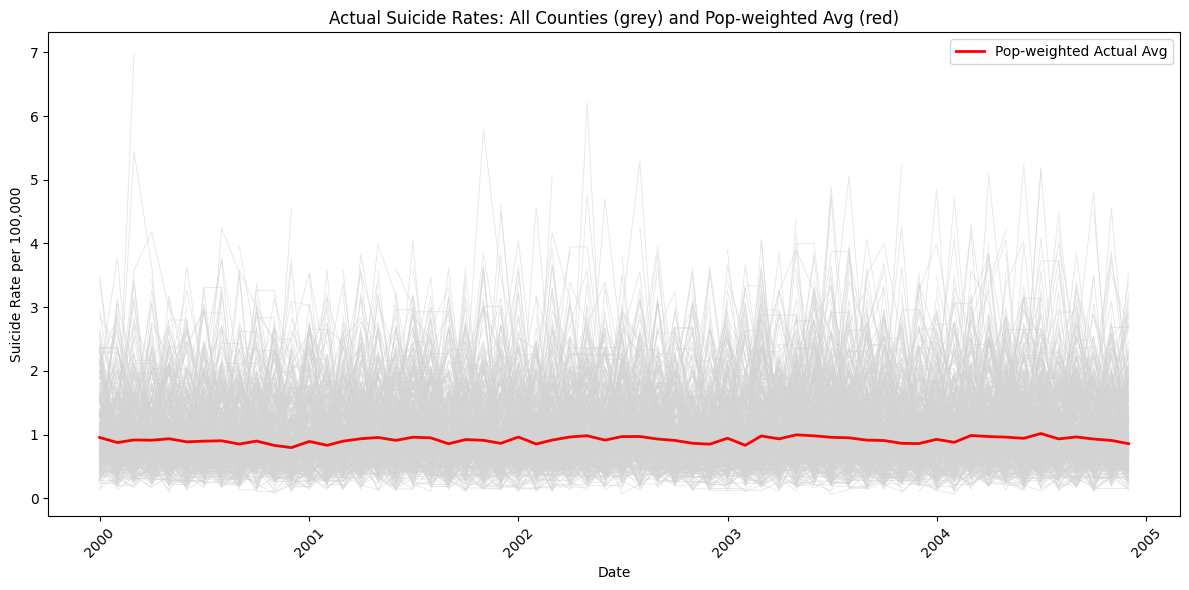

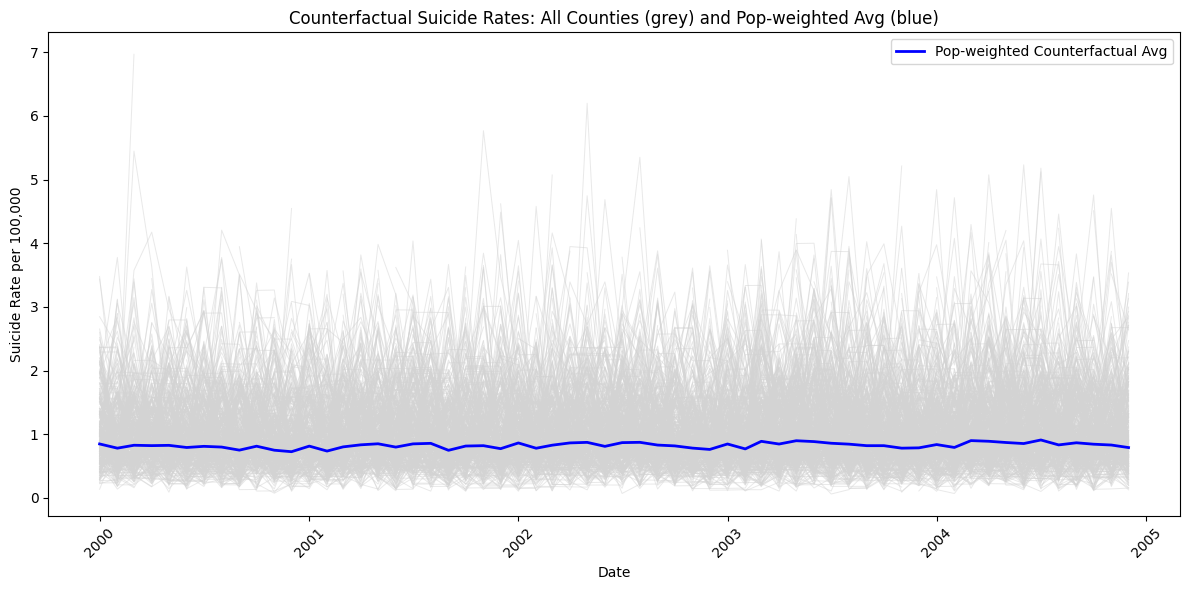

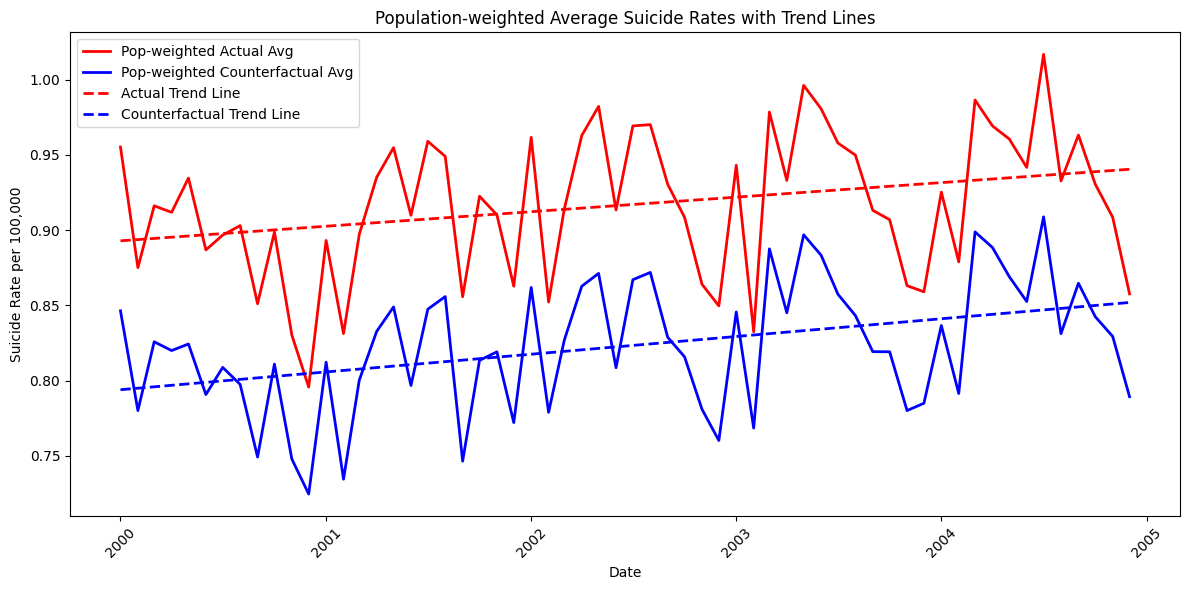

In [84]:
plot_all_counties_with_weighted_average_and_trends_intermonthweight(merged_data)

In [16]:
def plot_weighted_avg_with_trends(merged_data):
    """
    Plot population-weighted average suicide rate (actual and counterfactual)
    over time with linear trend lines. No time restrictions.

    Parameters:
        merged_data: DataFrame with columns year, month, fips, suiciderate, suiciderate_cf, population
    """
    # Create monthly date
    merged_data = merged_data.copy()
    merged_data['plot_date'] = pd.to_datetime(dict(year=merged_data['year'], month=merged_data['month'], day=1))
    merged_data = merged_data.sort_values(['fips', 'plot_date'])

    # Pivot to wide format: rows = date, columns = fips
    actual_pivot = merged_data.pivot(index='plot_date', columns='fips', values='suiciderate')
    cf_pivot = merged_data.pivot(index='plot_date', columns='fips', values='suiciderate_cf')

    # Population weights
    pop = merged_data.groupby('fips')['population'].mean()
    weights = pop / pop.sum()

    # Population-weighted average over time
    weighted_actual = actual_pivot.mul(weights, axis=1).sum(axis=1)
    weighted_cf = cf_pivot.mul(weights, axis=1).sum(axis=1)

    # Regressions for trend lines
    dates = weighted_actual.index
    ordinals = [d.toordinal() for d in dates]
    X = sm.add_constant(ordinals)
    actual_trend = sm.OLS(weighted_actual.values, X).fit().predict(X)
    cf_trend = sm.OLS(weighted_cf.values, X).fit().predict(X)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(dates, weighted_actual, color='red', linewidth=2, label='Pop-weighted Actual Avg')
    ax.plot(dates, weighted_cf, color='blue', linewidth=2, label='Pop-weighted Counterfactual Avg')
    ax.plot(dates, actual_trend, color='red', linestyle='--', linewidth=2, label='Actual Trend Line')
    ax.plot(dates, cf_trend, color='blue', linestyle='--', linewidth=2, label='Counterfactual Trend Line')

    ax.set_title('Population-weighted Suicide Rates with Trend Lines (Only for ~500 counties with full data)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


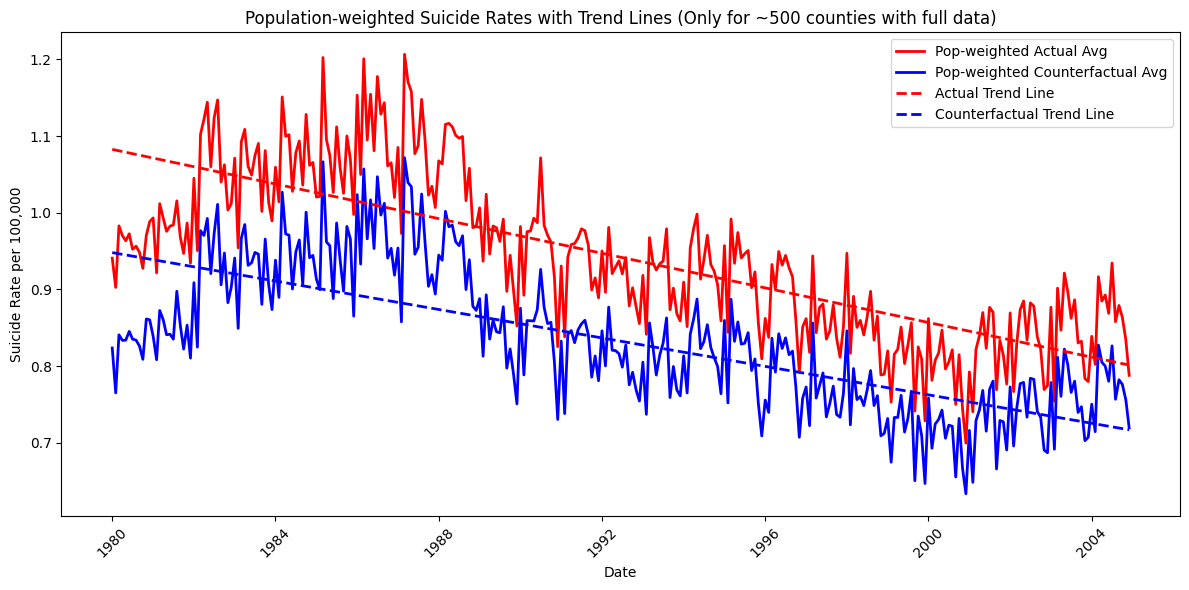

In [17]:
plot_weighted_avg_with_trends(merged_data)

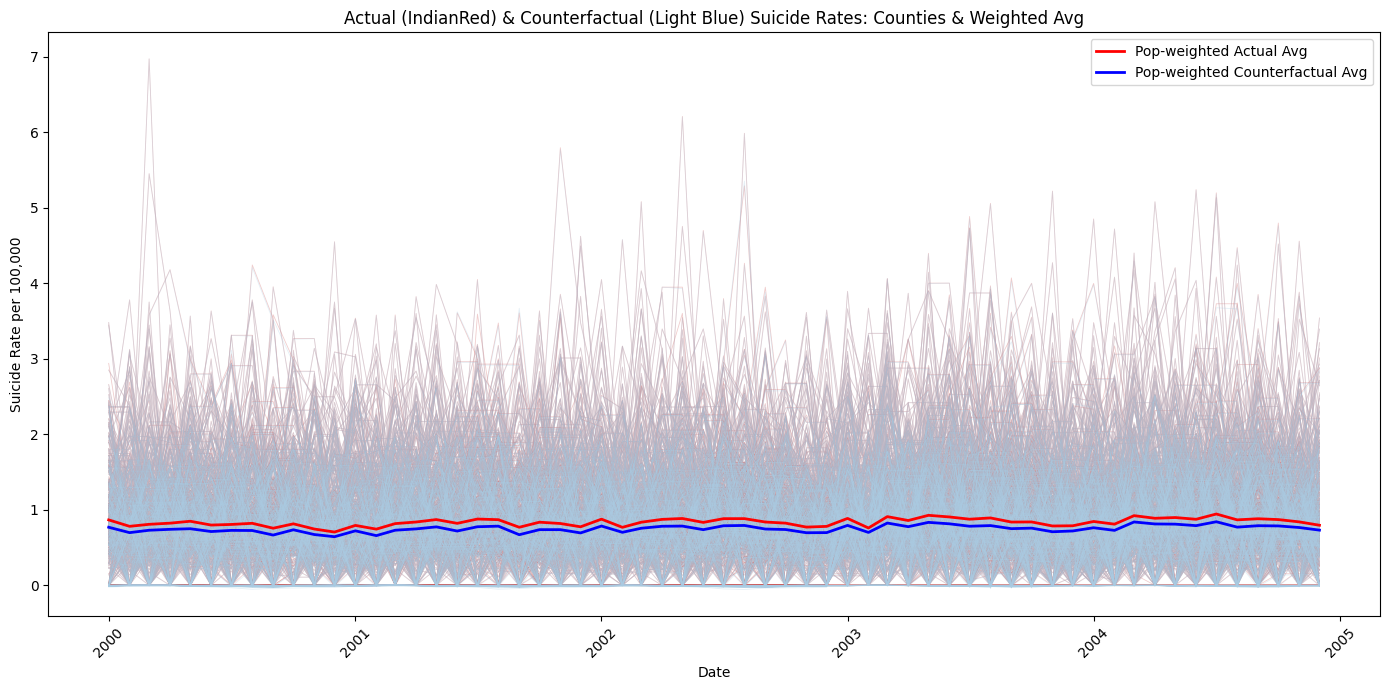

In [181]:
def plot_combined_actual_cf(merged_data):
    # Filter 2000-2004
    df = merged_data[(merged_data['year'] >= 2000) & (merged_data['year'] <= 2004)].copy()
    df['plot_date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))
    df = df.sort_values(['fips', 'year', 'month'])
    dates = sorted(df['plot_date'].unique())

    actual_pivot = df.pivot(index='plot_date', columns='fips', values='suiciderate')
    cf_pivot = df.pivot(index='plot_date', columns='fips', values='suiciderate_cf')

    pop = df.groupby('fips')['population'].mean()
    weights = pop / pop.sum()

    weighted_actual = actual_pivot.mul(weights, axis=1).sum(axis=1)
    weighted_cf = cf_pivot.mul(weights, axis=1).sum(axis=1)

    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot all counties actual in light red (IndianRed)
    for col in actual_pivot.columns:
        ax.plot(dates, actual_pivot[col], color='indianred', linewidth=0.6, alpha=0.3)

    # Plot all counties counterfactual in light blue
    for col in cf_pivot.columns:
        ax.plot(dates, cf_pivot[col], color='#A9CCE3', linewidth=0.6, alpha=0.3)

    # Overlay population-weighted averages
    ax.plot(dates, weighted_actual, color='red', linewidth=2, label='Pop-weighted Actual Avg')
    ax.plot(dates, weighted_cf, color='blue', linewidth=2, label='Pop-weighted Counterfactual Avg')

    ax.set_title('Actual (IndianRed) & Counterfactual (Light Blue) Suicide Rates: Counties & Weighted Avg')
    ax.set_xlabel('Date')
    ax.set_ylabel('Suicide Rate per 100,000')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Call the function
plot_combined_actual_cf(merged_data)


In [72]:
def plot_pct_attr_lines(all_pct_df, weighted_avg_series):
    """
    Plot all county-level % suicide attribution to climate change as light grey lines,
    overlaid with population-weighted average line in black.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    for col in all_pct_df.columns:
        ax.plot(all_pct_df.index, all_pct_df[col], color='lightgrey', linewidth=0.5, alpha=0.5)

    ax.plot(weighted_avg_series.index, weighted_avg_series.values,
            color='black', linewidth=2, label='Population-weighted Average')

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title('% of Suicide Rate Attributable to Climate Change (Monthly)')
    ax.set_ylabel('% Attributable to Climate Change')
    ax.set_xlabel('Date')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


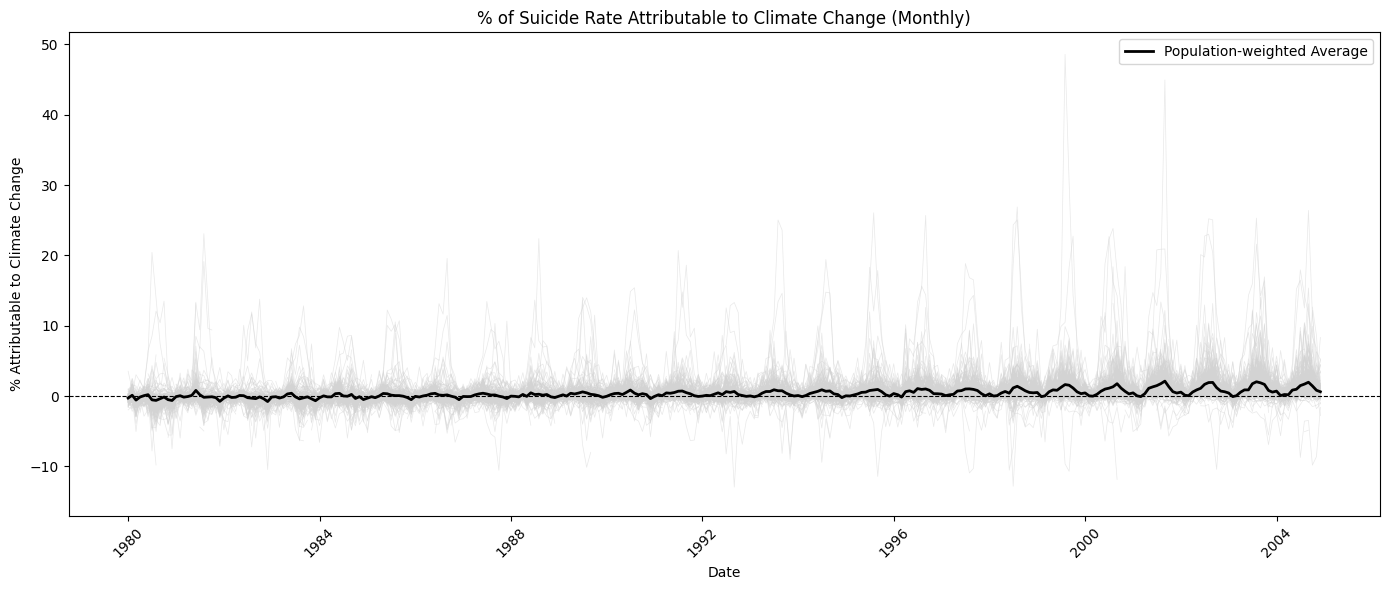

In [73]:
plot_pct_attr_lines(pivot_pct, weighted_pct_series)


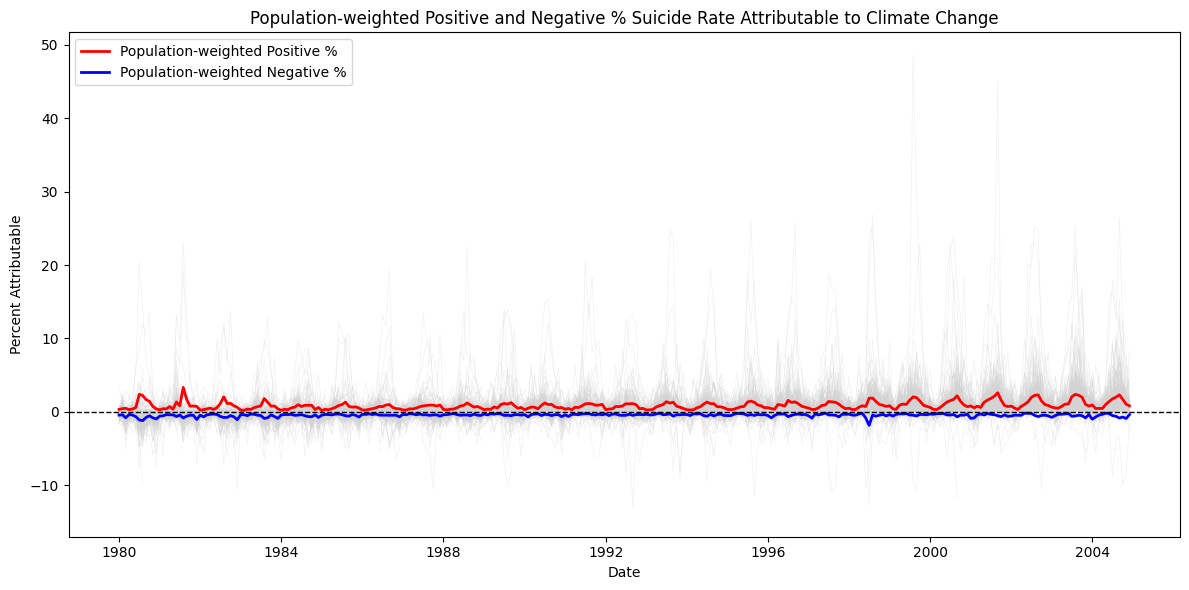

In [76]:

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot individual counties lightly
for fips in pivot_pct.columns:
    ax.plot(pivot_pct.index, pivot_pct[fips], color='lightgrey', alpha=0.3, linewidth=0.5)

# Plot weighted averages distinctly
ax.plot(weighted_pos.index, weighted_pos, label='Population-weighted Positive %', color='red', linewidth=2)
ax.plot(weighted_neg.index, weighted_neg, label='Population-weighted Negative %', color='blue', linewidth=2)

ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.set_title('Population-weighted Positive and Negative % Suicide Rate Attributable to Climate Change')
ax.set_xlabel('Date')
ax.set_ylabel('Percent Attributable')
ax.legend()
plt.tight_layout()
plt.show()


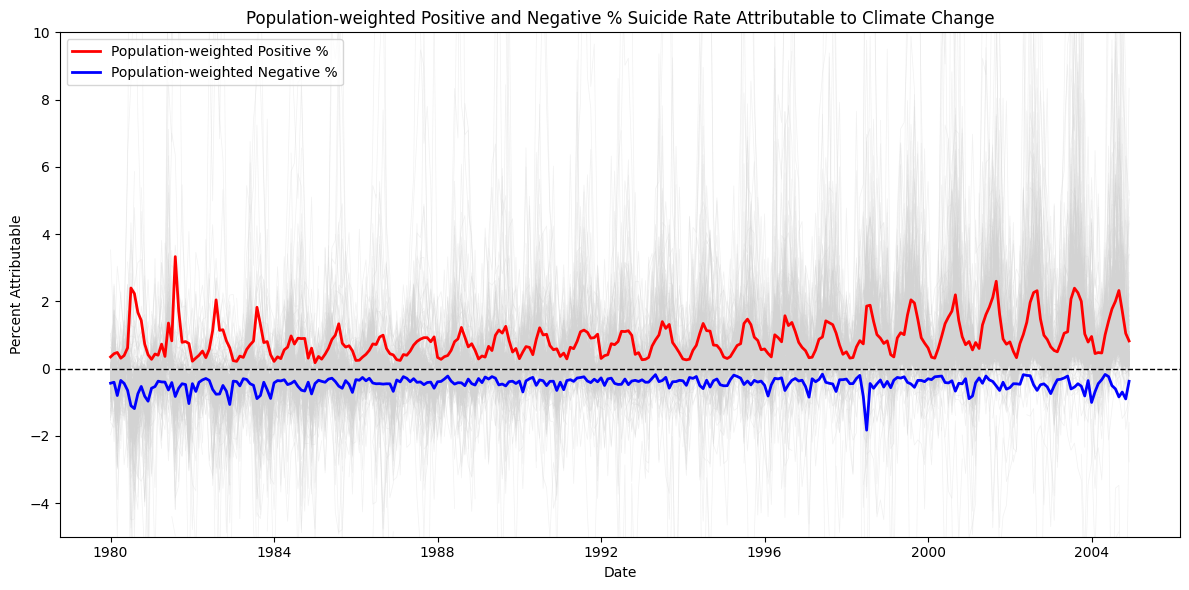

In [77]:
# ... (all previous code remains unchanged)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot individual counties lightly
for fips in pivot_pct.columns:
    ax.plot(pivot_pct.index, pivot_pct[fips], color='lightgrey', alpha=0.3, linewidth=0.5)

# Plot weighted averages distinctly
ax.plot(weighted_pos.index, weighted_pos, label='Population-weighted Positive %', color='red', linewidth=2)
ax.plot(weighted_neg.index, weighted_neg, label='Population-weighted Negative %', color='blue', linewidth=2)

ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.set_ylim(-5, 10)  # Manually set y-axis scale from -5 to +10

ax.set_title('Population-weighted Positive and Negative % Suicide Rate Attributable to Climate Change')
ax.set_xlabel('Date')
ax.set_ylabel('Percent Attributable')
ax.legend()
plt.tight_layout()
plt.show()


In [33]:
pivot_pct.mul(weights, axis=1)  # Will give NaN everywhere


fips,1003,1015,1055,1073,1081,1089,1097,1101,1103,1117,...,55063,55073,55079,55087,55101,55105,55117,55131,55133,55139
plot_date,,,,,,,,,,,,,,,,,,,,,
1980-01-01,-inf,-inf,-inf,-0.000152,inf,-0.000110,-0.000074,inf,0.000016,inf,...,-0.000135,-0.000366,NaN,-0.000258,NaN,-0.000400,NaN,-0.000029,-0.000604,-0.000393
1980-02-01,-0.000071,0.000067,inf,0.000291,inf,0.000018,0.000091,inf,0.000013,inf,...,0.000228,inf,NaN,0.000503,NaN,0.000191,NaN,0.000130,0.000450,inf
1980-03-01,-inf,-inf,-0.000239,-0.003047,-inf,-0.000428,-0.001255,-0.001350,-0.000475,-inf,...,-0.000285,-0.000352,NaN,-0.000122,NaN,-0.000530,NaN,-inf,0.000068,-0.000339
1980-04-01,-inf,-0.000126,-0.000087,-0.000673,-inf,-0.000034,-0.001395,-0.000959,-0.000066,-0.000096,...,-0.000101,-0.000458,NaN,-0.000284,NaN,-inf,NaN,inf,0.000707,-inf
1980-05-01,-0.000072,inf,inf,-0.000268,inf,-0.000033,-0.000811,inf,inf,inf,...,0.000068,0.000391,NaN,0.000168,NaN,0.000210,NaN,inf,0.001423,0.000152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004-08-01,0.000465,0.000273,inf,0.004316,0.000509,0.004369,0.005030,inf,0.000870,0.000836,...,0.000337,0.000308,NaN,0.000524,NaN,0.000260,NaN,0.000088,0.001457,0.000352
2004-09-01,0.001597,0.000714,0.001080,0.047200,inf,0.002475,0.003770,0.001047,0.001294,inf,...,0.000186,0.000361,NaN,0.000150,NaN,inf,NaN,0.000391,0.003710,0.000780
2004-10-01,inf,inf,0.000300,0.005067,0.000908,0.002098,0.003109,inf,inf,inf,...,0.000238,0.000243,NaN,0.000261,NaN,0.000277,NaN,0.000156,0.001180,0.000402


In [26]:
weighted_pct_series

plot_date
1980-01-01    NaN
1980-02-01    NaN
1980-03-01    NaN
1980-04-01    NaN
1980-05-01    NaN
             ... 
2004-08-01    NaN
2004-09-01    inf
2004-10-01    NaN
2004-11-01    NaN
2004-12-01    NaN
Length: 300, dtype: float64

## Summary Stats

In [80]:
# Drop NaNs and infinite values to avoid skewing stats
valid_pct = merged_data['pct_suiciderate_cc'].replace([np.inf, -np.inf], np.nan).dropna()

# Summary statistics
summary_stats = valid_pct.describe()

print("Summary statistics for pct_suiciderate_cc:")
print(summary_stats)

# Additionally, you can print specific stats like median, mean, std separately if you want
print(f"\nMedian: {valid_pct.median():.3f}")
print(f"Mean: {valid_pct.mean():.3f}")
print(f"Standard Deviation: {valid_pct.std():.3f}")

# Count of positive and negative values
print(f"\nCount positive values: {(valid_pct > 0).sum()}")
print(f"Count negative values: {(valid_pct < 0).sum()}")
print(f"Count zeros: {(valid_pct == 0).sum()}")


Summary statistics for pct_suiciderate_cc:
count    111469.000000
mean          0.280130
std           1.140781
min         -13.886406
25%          -0.138423
50%           0.135911
75%           0.515408
max          48.587366
Name: pct_suiciderate_cc, dtype: float64

Median: 0.136
Mean: 0.280
Standard Deviation: 1.141

Count positive values: 70576
Count negative values: 40893
Count zeros: 0


## NA Checks 

In [ ]:
# Convert fips to 5-digit string format (same as used in the merge)
slopes['fips_str'] = slopes['fips'].astype(int).astype(str).str.zfill(5)

# Get unique GEOIDs in the shapefile
geoid_set = set(usa_counties['GEOID'].unique())

# Check which slopes fips_str are not in the shapefile
unmatched_from_slopes = slopes[~slopes['fips_str'].isin(geoid_set)]

# Print results
if unmatched_from_slopes.empty:
    print("✅ All counties in the suicide data matched with the shapefile.")
else:
    print(f"❌ {len(unmatched_from_slopes)} counties from the suicide data did NOT match the shapefile:")
    print(unmatched_from_slopes[['fips', 'fips_str']])


# I county (fips 12025) doesn't match... this must be explored 


❌ 1 counties from the suicide data did NOT match the shapefile:
        fips fips_str
301  12025.0    12025


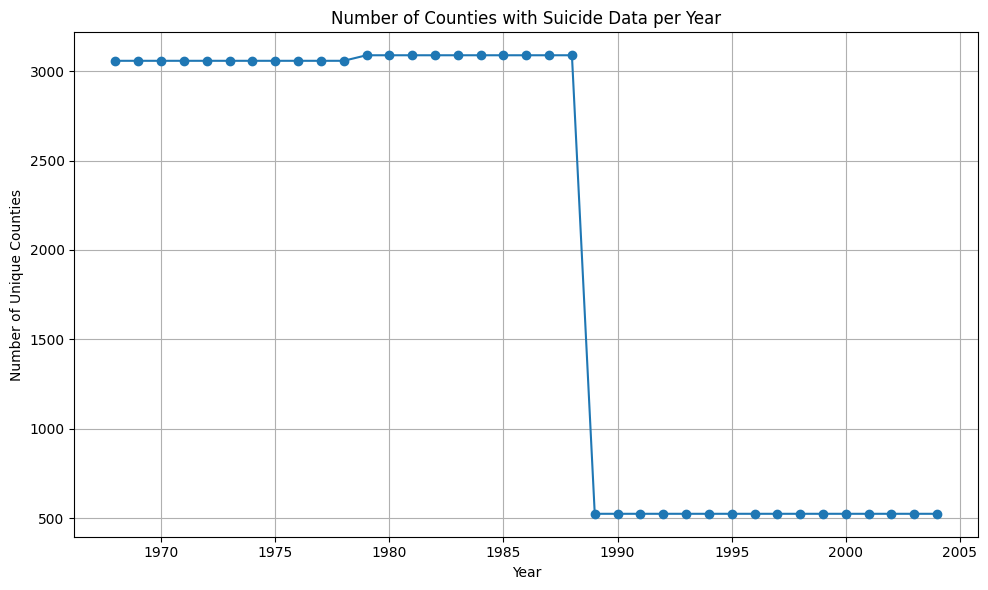

In [13]:
# Count unique counties per year
county_counts_by_year = (
    filtered_suicide
    .dropna(subset=['suiciderate'])  # Optional: drop rows with missing suicide rate
    .groupby('year')['fips']
    .nunique()
    .reset_index(name='num_counties')
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(county_counts_by_year['year'], county_counts_by_year['num_counties'], marker='o')
plt.title("Number of Counties with Suicide Data per Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Counties")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Drop rows with missing suiciderate
filtered_nonmissing = filtered_suicide.dropna(subset=['suiciderate'])

# Count unique counties per year
county_counts_by_year = (
    filtered_nonmissing
    .groupby('year')['fips']
    .nunique()
    .reset_index(name='num_counties')
)

# Split into periods
pre_1978 = county_counts_by_year[county_counts_by_year['year'] < 1979]
period_1978_1988 = county_counts_by_year[(county_counts_by_year['year'] >= 1979) & (county_counts_by_year['year'] < 1989)]
post_1989 = county_counts_by_year[county_counts_by_year['year'] >= 1989]

# Helper function
def stable_count(df):
    counts = df['num_counties'].unique()
    return counts[0] if len(counts) == 1 else -1

# Summary table
summary_table = pd.DataFrame({
    'period': ['Pre-1978', '1978–1988', '1989+'],
    'num_unique_counties': [
        stable_count(pre_1978),
        stable_count(period_1978_1988),
        stable_count(post_1989)
    ]
})

print(summary_table)


      period  num_unique_counties
0   Pre-1978                 3058
1  1978–1988                 3089
2      1989+                  524


In [18]:
# Filter to 1979 and later
filtered_1979plus = filtered_suicide[
    (filtered_suicide['year'] >= 1979) & 
    (~filtered_suicide['suiciderate'].isna())
]

# Get unique fips codes for each period
fips_1979_1988 = set(
    filtered_1979plus[(filtered_1979plus['year'] <= 1988)]['fips'].unique()
)
fips_1989plus = set(
    filtered_1979plus[(filtered_1979plus['year'] >= 1989)]['fips'].unique()
)

# 1. Counties with data for BOTH periods
counties_all_periods = fips_1979_1988 & fips_1989plus
print(f"✅ Counties with data for BOTH periods: {len(counties_all_periods)}")

# 2. Counties with data ONLY in 1979–1988
counties_only_1979_1988 = fips_1979_1988 - fips_1989plus
print(f"✅ Counties with data ONLY in 1979–1988: {len(counties_only_1979_1988)}")


✅ Counties with data for BOTH periods: 523
✅ Counties with data ONLY in 1979–1988: 2566


# Archive

## Diagnostics

In [ ]:

# NA summary on merged dasta
# Step 1: Group by county and find missing counts
missing_summary = subset.groupby('fips').apply(
    lambda g: pd.Series({
        'n_missing_actual': g['suiciderate'].isna().sum(),
        'n_missing_cf': g['suiciderate_cf'].isna().sum()
    })
).reset_index()

# Identify counties with any missing data
counties_with_nas = missing_summary[
    (missing_summary['n_missing_actual'] > 0) | (missing_summary['n_missing_cf'] > 0)
]

# Print summary
print(f"Number of counties with any NaNs: {len(counties_with_nas)}")
print(f"Average # of missing months (actual): {counties_with_nas['n_missing_actual'].mean():.2f}")
print(f"Average # of missing months (cf): {counties_with_nas['n_missing_cf'].mean():.2f}")


Number of unique counties in merged dataset: 522


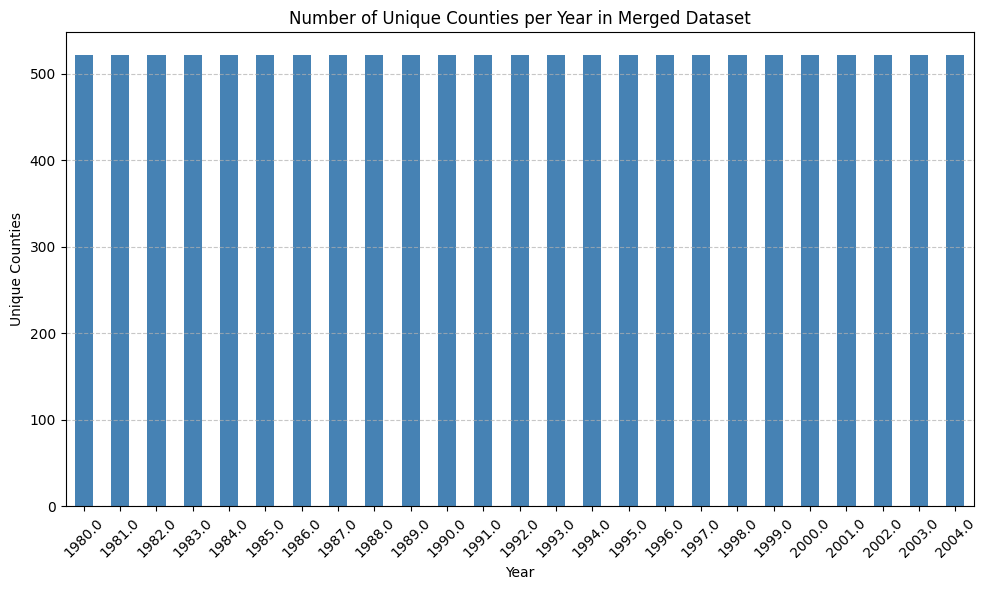

In [10]:
# diagnostics on merge

# Count matches
n_matched = len(merged)
n_suicide = len(complete_data_suicide)
n_attr = len(attribution_output_data)

unique_counties = merged['fips'].nunique()
print(f"Number of unique counties in merged dataset: {unique_counties}")

# Group by year and count unique counties
county_counts_per_year = merged.groupby('year')['fips'].nunique()

# Plot
plt.figure(figsize=(10, 6))
county_counts_per_year.plot(kind='bar', color='steelblue')

plt.title("Number of Unique Counties per Year in Merged Dataset")
plt.xlabel("Year")
plt.ylabel("Unique Counties")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()